# Evidence Retrieval Experiment Framework

This notebook acts as the central experiment framework for the dissertation.

It does not perform exploratory analysis of AVeriTeC; this is covered in the separate data inspection notebook. Instead, this notebook:

1. defines the experimental and reproducibility settings;
2. loads the prepared claims and candidate evidence collection;
3. executes each retrieval configuration through a common interface;
4. evaluates the resulting rankings using the same metrics;
5. records the configuration and environment associated with each run;

Retrieval implementations are contained in separate Python modules so that the experimental procedure remains consistent across methods.

## 1. Setup and Imports

### 1.1. Imports

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from datetime import datetime, timezone

import os
import sys
import json
import time
import random
import pickle
import psutil
import threading
import subprocess
from time import perf_counter
import matplotlib.pyplot as plt

import gc
import nltk
import torch
import numpy as np
import pandas as pd
import transformers
from tqdm.auto import tqdm
import sentence_transformers
from dotenv import load_dotenv
from rank_bm25 import BM25Okapi
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetProcessUtilization, NVMLError


### 1.2. Resource Monitor Utils

In [3]:
class ResourceMonitor:
    def __init__(self, interval=1.0):
        nvmlInit()
        self.gpu_handle = nvmlDeviceGetHandleByIndex(0)
        self.pid = os.getpid()
        self.last_gpu_timestamp = 0
        self.interval = interval
        self.process = psutil.Process(os.getpid())
        self.samples = []
        self.running = False
        self.thread = None

    def _sample(self):
        self.process.cpu_percent(None)

        start = time.perf_counter()

        while self.running:
            elapsed = time.perf_counter() - start
            cpu = (self.process.cpu_percent(None) / psutil.cpu_count())
            ram_gb = (self.process.memory_info().rss / 1024**3)
            gpu_gb = None
            gpu_util = self._gpu_process_utilisation() if torch.cuda.is_available() else None

            if torch.cuda.is_available():
                gpu_gb = (torch.cuda.memory_allocated() / 1024**3)

            self.samples.append({"time": elapsed, "cpu": cpu, "ram_gb": ram_gb, "gpu_util": gpu_util, "gpu_gb": gpu_gb})
            time.sleep(self.interval)

    def start(self):
        self.samples = []
        self.running = True
        self.thread = threading.Thread(target=self._sample, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False

        if self.thread is not None:
            self.thread.join()

        return pd.DataFrame(self.samples)

    def _gpu_process_utilisation(self):
        try:
            samples = nvmlDeviceGetProcessUtilization(self.gpu_handle, self.last_gpu_timestamp)

            gpu_util = 0.0

            for sample in samples:
                if sample.pid == self.pid:
                    gpu_util = float(sample.smUtil)

                    self.last_gpu_timestamp = max(self.last_gpu_timestamp, sample.timeStamp)

            return gpu_util

        except NVMLError:
            return 0.0


def plot_resources(data, title, smoothing_window=30):
    plot_data = data.copy()

    for column in ["cpu", "ram_gb", "gpu_gb", "gpu_util"]:
        if column in plot_data.columns:
            plot_data[column] = plot_data[column].rolling(window=smoothing_window, min_periods=1, center=True).mean()

    fig, ax = plt.subplots()

    ax.plot(plot_data["time"], plot_data["cpu"], label="CPU utilisation (%)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("CPU utilisation (%)")
    ax.set_title(title)
    ax.legend()

    plt.show()

    fig, ax = plt.subplots()

    ax.plot(plot_data["time"], plot_data["ram_gb"], label="RAM (GB)")

    if plot_data["gpu_gb"].notna().any():
        ax.plot(plot_data["time"], plot_data["gpu_gb"], label="GPU VRAM (GB)")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Memory (GB)")
    ax.set_title(title)
    ax.legend()

    plt.show()

    if "gpu_util" in plot_data.columns and plot_data["gpu_util"].notna().any():
        fig, ax = plt.subplots()

        ax.plot(plot_data["time"], plot_data["gpu_util"], label="GPU utilisation (%)")

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("GPU utilisation (%)")
        ax.set_ylim(0, 100)
        ax.set_title(title)
        ax.legend()

        plt.show()

def summarise_resources(data):
    summary = {"mean_cpu_pct": data["cpu"].mean(), "peak_cpu_pct": data["cpu"].max(), "mean_ram_gb": data["ram_gb"].mean(), "peak_ram_gb": data["ram_gb"].max()}

    if data["gpu_util"].notna().any():
        summary["mean_gpu_pct"] = data["gpu_util"].mean()
        summary["peak_gpu_pct"] = data["gpu_util"].max()
    else:
        summary["mean_gpu_pct"] = None
        summary["peak_gpu_pct"] = None

    if data["gpu_gb"].notna().any():
        summary["mean_gpu_gb"] = data["gpu_gb"].mean()
        summary["peak_gpu_gb"] = data["gpu_gb"].max()
    else:
        summary["mean_gpu_gb"] = None
        summary["peak_gpu_gb"] = None

    return summary

### 1.3. Local imports 

In [4]:
from fact_verification.data import CandidateStore, load_claims
from fact_verification.retrieval.bm25 import BM25Config, BM25Retriever
from fact_verification.retrieval.dense import DenseConfig,DenseRetriever
from fact_verification.retrieval.hybrid import HybridConfig, HybridRetriever
from fact_verification.reranking.cross_encoder import CrossEncoderConfig, CrossEncoderReranker
from fact_verification.evaluation import evaluate_retrieval, evaluate_retrieval_per_claim

## 2. Experimental Configuration and Reproducibility

All variables capable of changing the experimental outcome are defined here.
Values should not be changed inside individual retrieval sections.

### 2.1. Main Experiment Configuration

In [5]:
REPO_ROOT = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()).resolve()
load_dotenv(REPO_ROOT / ".env")

EXPERIMENT = {
    "experiment_name": "full_run",
    "seed": 67,
    "dataset": {"name": "AVeriTeC", "split": "dev", "revision": None, "root": os.environ.get("AVERITEC_ROOT")},
    "candidates": {"retrieval_unit": "sentence", "chunk_size": None, "chunk_overlap": None},
    "retrieval": {"retrieve_k": 100},
    "evaluation": {"cutoffs": [1, 5, 10, 20, 50, 100], "mrr_cutoff": 20},
    "bm25": {"k1": 1.5, "b": 0.75, "epsilon": 0.25, "lowercase": False},
    "dense": {"model_name": ("sentence-transformers/multi-qa-MiniLM-L6-cos-v1"), "revision": None, "batch_size": 64, 
              "device": ("cuda" if torch.cuda.is_available() else "cpu")},
    "hybrid": {"method": "rrf", "fusion_depth": 100, "rrf_constant": 60, "alpha": 0.5},
    "reranker": {"model_name": "cross-encoder/ms-marco-MiniLM-L6-v2", "revision": None, "batch_size": 32, "candidate_k": 100,
                 "output_k": 20, "device": "cuda" if torch.cuda.is_available() else "cpu"},
    "run": {"mode": "full_test", "claims": 500, "run_id": "full_run"},
}

DATA_ROOT = EXPERIMENT["dataset"]["root"]

if DATA_ROOT is None:
    raise RuntimeError("AVERITEC_ROOT is not set \n set it to the root directory of the AVeriTeC data")

DATA_ROOT = Path(DATA_ROOT)

### 2.2. Resolve configuration / paths

In [6]:
DATA_ROOT_VALUE = EXPERIMENT["dataset"]["root"]
RESULTS_ROOT = REPO_ROOT / "results"

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

if DATA_ROOT_VALUE is None:
    raise RuntimeError("AVERITEC_ROOT is not set \n set it to the root directory of the AVeriTeC data")

DATA_ROOT = Path(DATA_ROOT_VALUE).expanduser().resolve()
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"AVeriTeC data root does not exist: {DATA_ROOT}")

print(f"Repository root: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Results root: {RESULTS_ROOT}")

Repository root: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison
Data root: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\.local_data\averitec\2ca9dee23a2a
Results root: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results


### 2.3. Fix random seeds

In [7]:
SEED = EXPERIMENT["seed"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

### 2.4. Capture environment 

In [8]:
def get_git_commit():
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
    except Exception:
        return None

ENVIRONMENT = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version,
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "git_commit": get_git_commit(),
    "transformers_version": transformers.__version__,
    "sentence_transformers_version":sentence_transformers.__version__,
    "nltk_version": nltk.__version__,
}
pd.Series(ENVIRONMENT)

timestamp_utc                                     2026-09-06T22:31:45.139319+00:00
python_version                   3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:...
torch_version                                                         2.13.0+cu132
cuda_available                                                                True
cuda_version                                                                  13.2
gpu                                                        NVIDIA GeForce RTX 3060
git_commit                                ea39c43af40a346eadb4014f5d326d7353a5dff6
transformers_version                                                        5.15.0
sentence_transformers_version                                                5.7.0
nltk_version                                                                3.10.2
dtype: object

### 2.5. Initialise Run Directory

In [9]:
RUN_DIR = RESULTS_ROOT / EXPERIMENT["run"]["run_id"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Run directory:", RUN_DIR)

Run directory: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run


## 3. Load experimental data
Dataset structure and annotation characteristics are explored separately in
`01_averitec_data_inspection.ipynb`.  (NOTE: or whatever its called later)

Only the processed inputs required for retrieval are loaded here.

### 3.1. Initialise Claims and Candidate Store

In [10]:
claims = load_claims(root=DATA_ROOT, split=EXPERIMENT["dataset"]["split"])

if EXPERIMENT["run"]["mode"] == "pilot":
    claims = claims.sample(n=EXPERIMENT["run"]["claims"], random_state=EXPERIMENT["seed"]).sort_values(
        "claim_id").reset_index(drop=True)

candidate_store = CandidateStore(root=DATA_ROOT, split=EXPERIMENT["dataset"]["split"], 
                                 retrieval_unit=EXPERIMENT["candidates"]["retrieval_unit"], 
                                 chunk_size=EXPERIMENT["candidates"]["chunk_size"], 
                                 chunk_overlap=EXPERIMENT["candidates"]["chunk_overlap"])

if EXPERIMENT["run"]["mode"] == "full_test":
    assert len(claims) == EXPERIMENT["run"]["claims"], (f"expected {EXPERIMENT['run']['claims']} claims, but loaded {len(claims)}")
    assert len(candidate_store) == len(claims), (f"claims: {len(claims)}, knowledge stores: {len(candidate_store)}")

print(f"Claims loaded: {len(claims):,}")
print(f"Knowledge-store claims: {len(candidate_store):,}")
print(f"Retrieval unit: {candidate_store.retrieval_unit}")
print(f"Knowledge store: {candidate_store.directory}")

Claims loaded: 500
Knowledge-store claims: 500
Retrieval unit: sentence
Knowledge store: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\.local_data\averitec\2ca9dee23a2a\knowledge_store\dev\output_dev


### 3.2. Candidate Generation Sanity Check

In [11]:
EXAMPLE_CLAIM_ID = claims.iloc[0]["claim_id"]

example_claim = claims.loc[claims["claim_id"] == EXAMPLE_CLAIM_ID, "claim"].iloc[0]
example_candidates = candidate_store.load_claim(EXAMPLE_CLAIM_ID)

print(f"Claim ID: {EXAMPLE_CLAIM_ID}")
print(f"Claim: {example_claim}")
print(f"Candidates generated: {len(example_candidates):,}")

display(example_candidates[["candidate_id", "source_url", "text", "sentence_start", "sentence_end"]].head(10))

Claim ID: 0
Claim: In a letter to Steve Jobs, Sean Connery refused to appear in an apple commercial.
Candidates generated: 534,488


,candidate_id,source_url,text,sentence_start,sentence_end
0,0:0:0,https://web.archive.org/web/20201129141238/htt...,"San Francisco, CA — It’s easy to appreciate iM...",0,0
1,0:0:1,https://web.archive.org/web/20201129141238/htt...,"In fact, Apple’s concerns over the brand-new c...",1,1
2,0:0:2,https://web.archive.org/web/20201129141238/htt...,The surprising story comes to light in iMacula...,2,2
3,0:0:3,https://web.archive.org/web/20201129141238/htt...,"As Ms. Woods spins the tale, it was just weeks...",3,3
4,0:0:4,https://web.archive.org/web/20201129141238/htt...,"Steve Jobs, a lifelong fan of James Bond (he’d...",4,4
5,0:0:5,https://web.archive.org/web/20201129141238/htt...,"“The ad was of dubious quality, clearly not on...",5,5
6,0:0:6,https://web.archive.org/web/20201129141238/htt...,"Though Steve had a thing for Sean Connery, the...",6,6
7,0:0:7,https://web.archive.org/web/20201129141238/htt...,Connery’s final rejection was accompanied by a...,7,7
8,0:0:8,https://web.archive.org/web/20201129141238/htt...,"Needless to say, iMac managed to “survive” wit...",8,8
9,0:0:9,https://web.archive.org/web/20201129141238/htt...,iMaculate Conception reveals a number of other...,9,9


#### 3.2.1. Candidate store sanity checks

In [12]:
assert not example_candidates.empty
assert example_candidates["candidate_id"].is_unique
assert example_candidates["text"].notna().all()

required_columns = {"claim_id", "candidate_id", "source_url", "text"}
missing = required_columns - set(example_candidates.columns)

assert not missing, (f"Candidate store is missing required fields: {sorted(missing)}")

### 3.4. Initialise Run State

In [13]:
RUNTIMES = {}
RESOURCE_USAGE = {}
RUN_SUMMARY = {}

def validate_ranked_results(results, expected_claims, expected_k, method):
    assert results["claim_id"].nunique() == expected_claims, (f"{method}: expected {expected_claims} claims, found {results['claim_id'].nunique()}")

    counts = results.groupby("claim_id").size()

    assert (counts == expected_k).all(), (f"{method}: not every claim contains {expected_k} ranked results")
    assert results["rank"].between(1, expected_k).all()

    print(f"{method} output validated.")

## 4. Primary Retrieval Experiment
Each retrieval method is executed using the same claims, candidate store and
retrieval depth defined in the experimental configuration.

### 4.1. BM25 Retriever

#### 4.1.1. Initialise BM25 Retriever

In [14]:
bm25 = BM25Retriever(config=BM25Config(**EXPERIMENT["bm25"]))

print("BM25 retriever initialised.")

BM25 retriever initialised.


#### 4.1.1. Run BM25 

Also initialises runtime dictionaries (RUNTIMES, RESOURCE_USAGE, RUN_SUMMARY)

BM25 already completed. Loading saved results...
BM25 results: 50,000
Runtime: 15425.06s


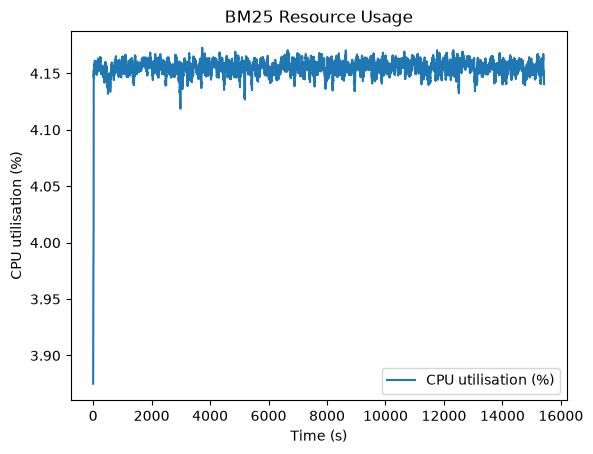

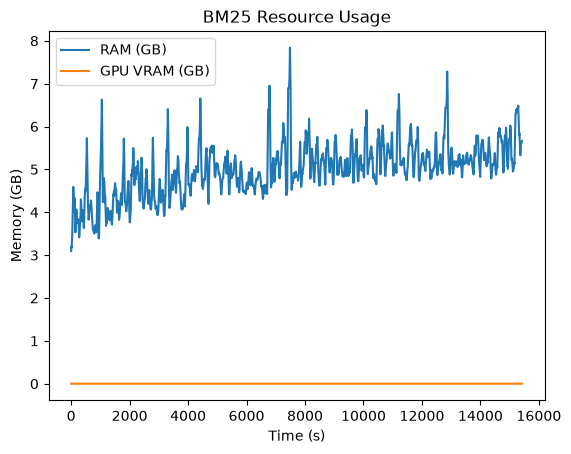

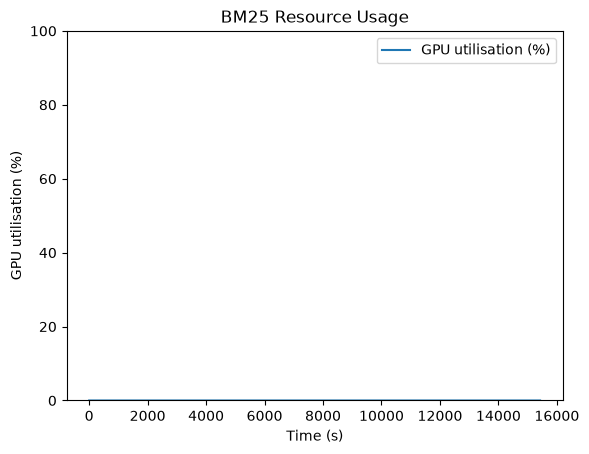

BM25 output validated.


In [15]:
BM25_RESULTS_PATH = RUN_DIR / "bm25_results.pkl"
BM25_RESOURCE_PATH = RUN_DIR / "bm25_resource_usage.pkl"
BM25_STATE_PATH = RUN_DIR / "bm25_state.pkl"


if (BM25_RESULTS_PATH.exists() and BM25_RESOURCE_PATH.exists() and BM25_STATE_PATH.exists()):
    print("BM25 already completed. Loading saved results...")

    bm25_results = pd.read_pickle(BM25_RESULTS_PATH)
    RESOURCE_USAGE["bm25"] = pd.read_pickle(BM25_RESOURCE_PATH)

    bm25_state = pd.read_pickle(BM25_STATE_PATH)

    RUNTIMES["bm25"] = bm25_state["runtime_seconds"]
    RUN_SUMMARY["bm25"] = bm25_state["summary"]

else:
    print("Running BM25 retrieval...")

    monitor = ResourceMonitor()
    monitor.start()

    start = perf_counter()

    bm25_results = bm25.retrieve_batch(claims=claims, candidates=candidate_store, k=EXPERIMENT["retrieval"]["retrieve_k"])

    RUNTIMES["bm25"] = perf_counter() - start
    RESOURCE_USAGE["bm25"] = monitor.stop()

    RUN_SUMMARY["bm25"] = {"claims": len(claims), "results": len(bm25_results), "runtime_seconds": RUNTIMES["bm25"], **summarise_resources(RESOURCE_USAGE["bm25"])}

    # persist immediately after successful completion
    bm25_results.to_pickle(BM25_RESULTS_PATH)

    RESOURCE_USAGE["bm25"].to_pickle(BM25_RESOURCE_PATH)

    pd.to_pickle({"runtime_seconds": RUNTIMES["bm25"], "summary": RUN_SUMMARY["bm25"]}, BM25_STATE_PATH)

    print("BM25 retrieval completed and saved.")

print(f"BM25 results: {len(bm25_results):,}")
print(f"Runtime: {RUNTIMES['bm25']:.2f}s")

plot_resources(RESOURCE_USAGE["bm25"], "BM25 Resource Usage")

validate_ranked_results(bm25_results, len(claims), 100, "BM25")

### 4.2. Dense Retriever

#### 4.2.1. Initialise Dense Retriever

In [16]:
dense = DenseRetriever(config=DenseConfig(**EXPERIMENT["dense"]))

print("Dense retriever initialised.")
print("Device:", dense.model.device)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Dense retriever initialised.
Device: cuda:0


#### 4.2.2. Run Dense Retriever

Dense retrieval already completed. Loading saved results...
Dense retrieval output validated.
Dense results: 50,000
Dense claims: 500
Runtime: 208594.98s (57.94h)


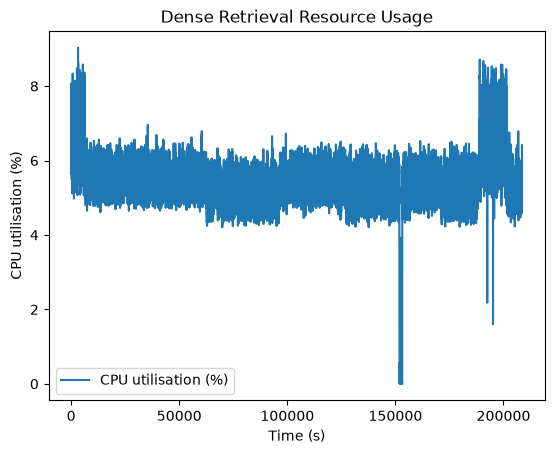

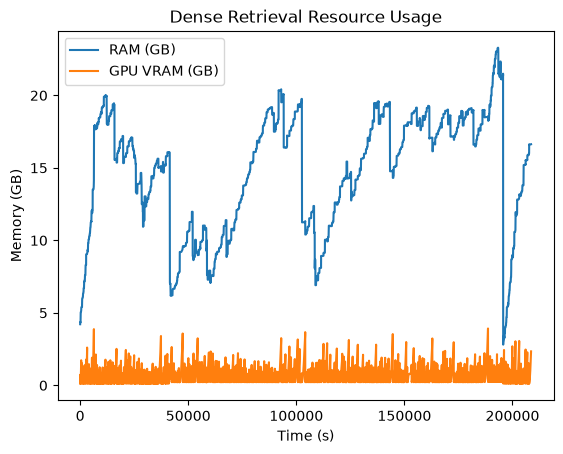

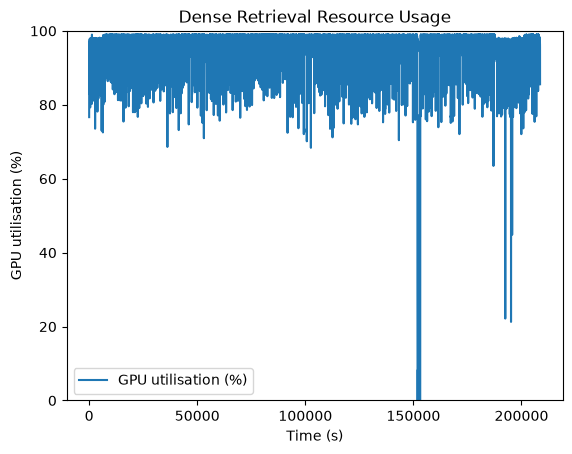

In [17]:
DENSE_RESULTS_PATH = RUN_DIR / "dense_results.pkl"
DENSE_CHECKPOINT_PATH = RUN_DIR / "dense_checkpoint.pkl"
DENSE_RESOURCE_PATH = RUN_DIR / "dense_resource_usage.pkl"
DENSE_STATE_PATH = RUN_DIR / "dense_state.pkl"

CHECKPOINT_EVERY = 2

# load a completed dense run if one already exists
if (DENSE_RESULTS_PATH.exists() and DENSE_RESOURCE_PATH.exists() and DENSE_STATE_PATH.exists()):
    print("Dense retrieval already completed. Loading saved results...")
    
    dense_results = pd.read_pickle(DENSE_RESULTS_PATH)
    RESOURCE_USAGE["dense"] = pd.read_pickle(DENSE_RESOURCE_PATH)
    dense_state = pd.read_pickle(DENSE_STATE_PATH)

    RUNTIMES["dense"] = dense_state["runtime_seconds"]
    RUN_SUMMARY["dense"] = dense_state["summary"]

# otherwise start or resume an incomplete dense run
else:
    # load previous retrieval progress
    if DENSE_CHECKPOINT_PATH.exists():
        dense_results = pd.read_pickle(DENSE_CHECKPOINT_PATH)
        completed_claims = set(dense_results["claim_id"].unique())

        print(f"Resuming dense retrieval: {len(completed_claims):,} claims already complete")

    else:
        dense_results = pd.DataFrame()
        completed_claims = set()

        print("Starting dense retrieval from the beginning.")

    # load previous runtime state
    if DENSE_STATE_PATH.exists():
        dense_state = pd.read_pickle(DENSE_STATE_PATH)
        previous_runtime = dense_state.get("runtime_seconds", 0.0)

    else:
        previous_runtime = 0.0

    # load previous resource samples
    if DENSE_RESOURCE_PATH.exists():
        previous_usage = pd.read_pickle(DENSE_RESOURCE_PATH)
    else:
        previous_usage = pd.DataFrame()

    # determine which claims still require retrieval
    remaining_claims = claims[~claims["claim_id"].isin(completed_claims)]

    print(f"Remaining claims: {len(remaining_claims):,}")

    # Start resource monitoring
    monitor = ResourceMonitor()
    monitor.start()

    start = perf_counter()
    try:
        # run remaining claims
        for claim_index, (_, claim) in enumerate(tqdm(remaining_claims.iterrows(), total=len(remaining_claims), 
                                                      desc="DenseRetriever", unit="claim"), start=1):
            claim_id = claim["claim_id"]
            claim_candidates = candidate_store.load_claim(claim_id)
            claim_candidates = claim_candidates.drop(columns=["claim_id"], errors="ignore")

            result = dense.retrieve(query=claim["claim"], candidates=claim_candidates, k=EXPERIMENT["retrieval"]["retrieve_k"])
            result.insert(0, "claim_id", claim_id)
            dense_results = pd.concat([dense_results, result], ignore_index=True)

            del claim_candidates
            del result

            gc.collect()

            # checkpoint every N completed claims
            if (claim_index % CHECKPOINT_EVERY == 0 or claim_index == len(remaining_claims)):
                dense_results.to_pickle(DENSE_CHECKPOINT_PATH)

                current_runtime = (previous_runtime + (perf_counter() - start))

                # snapshot resource samples collected during the current session
                current_usage = pd.DataFrame(monitor.samples).copy()

                if not current_usage.empty:
                    current_usage["time"] += (previous_runtime)

                checkpoint_usage = pd.concat([previous_usage, current_usage], ignore_index=True)
                checkpoint_usage.to_pickle(DENSE_RESOURCE_PATH)

                pd.to_pickle({"runtime_seconds": current_runtime, "completed_claims": int(dense_results["claim_id"].nunique())}, 
                             DENSE_STATE_PATH)

    # if retrieval fails, preserve all completed work before reraising exception
    except Exception:
        session_usage = monitor.stop()
        current_runtime = (previous_runtime + (perf_counter() - start))
        dense_results.to_pickle(DENSE_CHECKPOINT_PATH)

        if not session_usage.empty:
            session_usage = session_usage.copy()

            session_usage["time"] += (previous_runtime)

        checkpoint_usage = pd.concat([previous_usage, session_usage], ignore_index=True)
        checkpoint_usage.to_pickle(DENSE_RESOURCE_PATH)


        pd.to_pickle({"runtime_seconds": current_runtime, "completed_claims": int(dense_results["claim_id"].nunique())}, 
                     DENSE_STATE_PATH)

        print("dense retrieval interrupted, completed progress has been checkpointed")
        raise

    # finalise successful dense retrieval
    session_usage = monitor.stop()
    session_runtime = (perf_counter() - start)
    RUNTIMES["dense"] = (previous_runtime + session_runtime)


    if not session_usage.empty:
        session_usage = session_usage.copy()
        session_usage["time"] += (previous_runtime)


    RESOURCE_USAGE["dense"] = pd.concat([previous_usage, session_usage], ignore_index=True)
    dense_results = (dense_results.sort_values(["claim_id", "rank"]).reset_index(drop=True))
    RUN_SUMMARY["dense"] = {"claims": len(claims), "results": len(dense_results), "runtime_seconds": RUNTIMES["dense"], 
                            **summarise_resources(RESOURCE_USAGE["dense"])}

    # save completed dense run
    dense_results.to_pickle(DENSE_RESULTS_PATH)
    RESOURCE_USAGE["dense"].to_pickle(DENSE_RESOURCE_PATH)

    pd.to_pickle({"runtime_seconds": RUNTIMES["dense"], "summary": RUN_SUMMARY["dense"], 
                  "completed_claims": int(dense_results["claim_id"].nunique())}, DENSE_STATE_PATH)

    # final result now exists, so partial checkpoint no longer required
    if DENSE_CHECKPOINT_PATH.exists():
        DENSE_CHECKPOINT_PATH.unlink()

    print("dense retrieval completed and saved")

# validate loaded or newly generated output
expected_claims = len(claims)

expected_k = (EXPERIMENT["retrieval"]["retrieve_k"])
actual_claims = (dense_results["claim_id"].nunique())
results_per_claim = (dense_results.groupby("claim_id").size())

assert actual_claims == expected_claims, (f"dense: expected {expected_claims} claims, found {actual_claims}")
assert (results_per_claim == expected_k).all(), (f"dense: not every claim contains {expected_k} retrieved candidates")
assert dense_results["rank"].between(1, expected_k).all(), ("dense: invalid rank values detected")

# display summary
print("Dense retrieval output validated.")
print(f"Dense results: {len(dense_results):,}")
print(f"Dense claims: {actual_claims:,}")
print(f"Runtime: {RUNTIMES['dense']:.2f}s ({RUNTIMES['dense'] / 3600:.2f}h)")

plot_resources(RESOURCE_USAGE["dense"], "Dense Retrieval Resource Usage")

### 4.3. Hybrid Retriever

#### 4.3.1. Initialise Hybrid Retriever
This section essentially just consumes the existing results, opposed to regenerating the experiment results for both BM25 and DPR

In [18]:
hybrid = HybridRetriever(lexical_retriever=bm25, dense_retriever=dense, config=HybridConfig(**EXPERIMENT["hybrid"]))

print("Hybrid retriever initialised.")

Hybrid retriever initialised.


#### 4.3.2. Run Hybrid Fusion

In [19]:
HYBRID_RESULTS_PATH = RUN_DIR / "hybrid_results.pkl"
HYBRID_STATE_PATH = RUN_DIR / "hybrid_state.pkl"


#  load completed hybrid results if available
if (HYBRID_RESULTS_PATH.exists() and HYBRID_STATE_PATH.exists()):
    print("Hybrid fusion already completed. Loading saved results...")

    hybrid_results = pd.read_pickle(HYBRID_RESULTS_PATH)
    hybrid_state = pd.read_pickle(HYBRID_STATE_PATH)

    RUNTIMES["hybrid_fusion"] = hybrid_state["fusion_runtime_seconds"]
    RUNTIMES["hybrid_total"] = hybrid_state["total_runtime_seconds"]
    RUN_SUMMARY["hybrid"] = hybrid_state["summary"]


# otherwise run the fusion
else:
    print("Running hybrid RRF fusion...")
    start = perf_counter()

    hybrid_results = hybrid.fuse_batch(lexical_results=bm25_results, dense_results=dense_results, 
                                       k=EXPERIMENT["retrieval"]["retrieve_k"])

    RUNTIMES["hybrid_fusion"] = perf_counter() - start
    RUNTIMES["hybrid_total"] = RUNTIMES["bm25"] + RUNTIMES["dense"] + RUNTIMES["hybrid_fusion"]
    RUN_SUMMARY["hybrid"] = {"claims": len(claims), "results": len(hybrid_results), "runtime_seconds": RUNTIMES["hybrid_fusion"], 
                             "total_runtime_seconds": RUNTIMES["hybrid_total"]}


    # save completed hybrid output
    hybrid_results.to_pickle(HYBRID_RESULTS_PATH)

    pd.to_pickle({"fusion_runtime_seconds": RUNTIMES["hybrid_fusion"], "total_runtime_seconds": RUNTIMES["hybrid_total"], 
                  "summary": RUN_SUMMARY["hybrid"]}, HYBRID_STATE_PATH)
    print("Hybrid fusion completed and saved.")

# display results
print(f"Hybrid results: {len(hybrid_results):,}")
print(f"Fusion runtime: {RUNTIMES['hybrid_fusion']:.4f}s")
print(f"Total hybrid pipeline runtime: {RUNTIMES['hybrid_total'] / 3600:.2f}h")

validate_ranked_results(hybrid_results, len(claims), 100, "Hybrid")

# release first stage retrieval models before loading crossencoder
if "hybrid" in globals():
    del hybrid

if "dense" in globals():
    del dense

if "bm25" in globals():
    del bm25

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


Hybrid fusion already completed. Loading saved results...
Hybrid results: 50,000
Fusion runtime: 4.5711s
Total hybrid pipeline runtime: 62.23h
Hybrid output validated.


### 4.4. Cross-Encoder Reranker

#### 4.4.1. Initialse Cross-Encoder Reranker
As with the hybrid retrieval, the reranker should consume candidate results from one of the first-stage systems

In [20]:
reranker_config = EXPERIMENT["reranker"]
cross_encoder = CrossEncoderReranker(config=CrossEncoderConfig(model_name=reranker_config["model_name"], 
                                                               revision=reranker_config["revision"], 
                                                               batch_size=reranker_config["batch_size"], 
                                                               device=reranker_config["device"]))
print("Cross-encoder reranker initialised.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Cross-encoder reranker initialised.


#### 4.4.2. Run Cross-Encoder Reranking

Cross-encoder reranking already completed. Loading saved results...
Reranked results: 10,000
Cross-encoder runtime: 26.40s
Complete reranked pipeline runtime: 62.24h


,claim_id,candidate_id,source_url,text,source_index,sentence_start,sentence_end,source_type,source_query,score,rank,method,first_stage_score,first_stage_rank,first_stage_method
0,0,0:32:1,https://www.cnet.com/culture/fake-sean-connery...,"First, the bad news. Sean Connery never actual...",32,1,1,question_duplicate,Sean Connery refusal letter Steve Jobs apple c...,8.725554,1,cross_encoder,0.031778,2,hybrid-rrf
1,0,0:34:0,https://www.dailymail.co.uk/news/article-20063...,'I am f****** James Bond': Sean Connery letter...,34,0,0,question_duplicate,Sean Connery refusal letter Steve Jobs apple c...,8.325946,2,cross_encoder,0.029670,4,hybrid-rrf
2,0,0:195:0,https://www.businessinsider.com/james-bond-sea...,This is a letter Sean Connery wrote didn't wri...,195,0,0,question_duplicate,Background information on Sean Connery's invol...,7.819639,3,cross_encoder,0.032258,1,hybrid-rrf
3,0,0:34:4,https://www.dailymail.co.uk/news/article-20063...,Do you know who I am? A faked letter from Jame...,34,4,4,question_duplicate,Sean Connery refusal letter Steve Jobs apple c...,7.700882,4,cross_encoder,0.026280,8,hybrid-rrf
4,0,0:37:2,https://www.telegraph.co.uk/culture/film/james...,"In the letter, 'Connery' wrote that he did not...",37,2,2,question_duplicate,Sean Connery refusal letter Steve Jobs apple c...,5.896132,5,cross_encoder,0.024634,14,hybrid-rrf


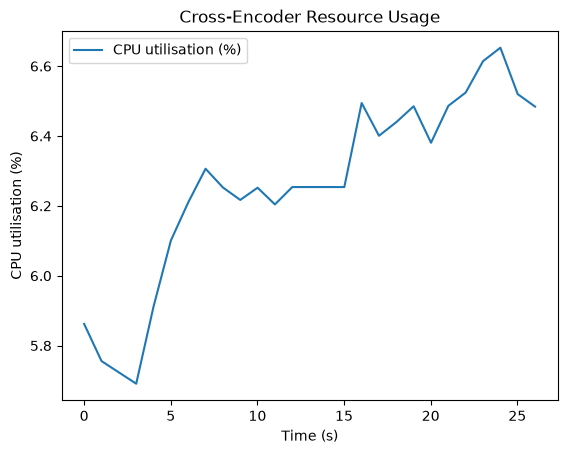

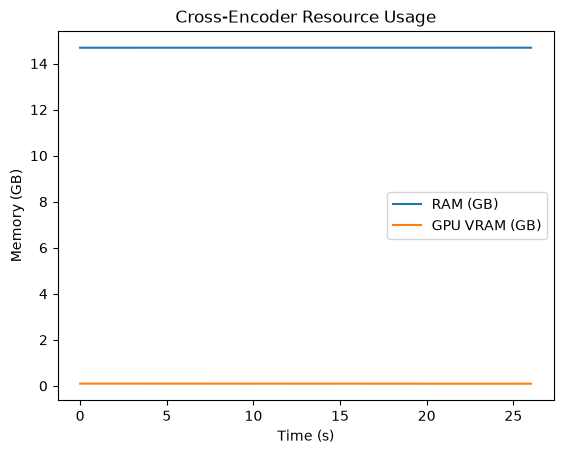

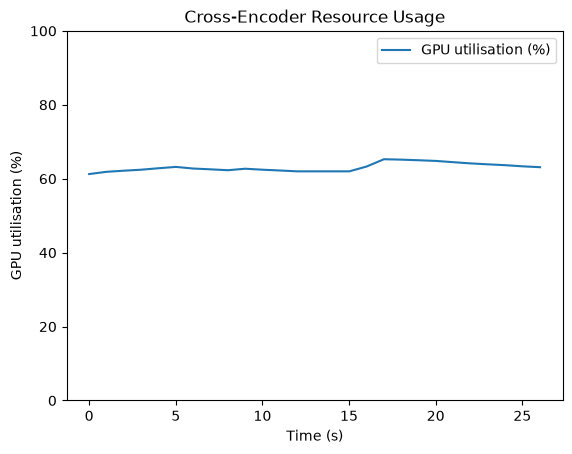

Cross-Encoder output validated.


In [21]:
CROSS_ENCODER_RESULTS_PATH = RUN_DIR / "cross_encoder_results.pkl"
CROSS_ENCODER_RESOURCE_PATH = RUN_DIR / "cross_encoder_resource_usage.pkl"
CROSS_ENCODER_STATE_PATH = RUN_DIR / "cross_encoder_state.pkl"


# load completed results if available

if (CROSS_ENCODER_RESULTS_PATH.exists() and CROSS_ENCODER_RESOURCE_PATH.exists() and CROSS_ENCODER_STATE_PATH.exists()):
    print("Cross-encoder reranking already completed. Loading saved results...")

    reranked_results = pd.read_pickle(CROSS_ENCODER_RESULTS_PATH)

    RESOURCE_USAGE["cross_encoder"] = pd.read_pickle(CROSS_ENCODER_RESOURCE_PATH)

    cross_encoder_state = pd.read_pickle(CROSS_ENCODER_STATE_PATH)

    RUNTIMES["cross_encoder"] = cross_encoder_state["runtime_seconds"]
    RUNTIMES["cross_encoder_total"] = cross_encoder_state["total_runtime_seconds"]
    RUN_SUMMARY["cross_encoder"] = cross_encoder_state["summary"]


# otherwise run reranker

else:
    print("Running cross-encoder reranking...")

    monitor = ResourceMonitor()
    monitor.start()

    start = perf_counter()

    reranked_results = cross_encoder.rerank_batch(claims = claims, candidates = hybrid_results, 
                                                  candidate_k = EXPERIMENT["reranker"]["candidate_k"], 
                                                  output_k = EXPERIMENT["reranker"]["output_k"])

    RUNTIMES["cross_encoder"] = perf_counter() - start

    RESOURCE_USAGE["cross_encoder"] = monitor.stop() 


    # total cost of producing final reranked ranking
    RUNTIMES["cross_encoder_total"] = RUNTIMES["hybrid_total"] + RUNTIMES["cross_encoder"]

    RUN_SUMMARY["cross_encoder"] = {"claims": len(claims), "results": len(reranked_results), 
                                    "runtime_seconds": RUNTIMES["cross_encoder"], 
                                    "total_runtime_seconds": RUNTIMES["cross_encoder_total"], 
                                    **summarise_resources(RESOURCE_USAGE["cross_encoder"])}


    # persist completed outputs immediately
    reranked_results.to_pickle(CROSS_ENCODER_RESULTS_PATH)

    RESOURCE_USAGE["cross_encoder"].to_pickle(CROSS_ENCODER_RESOURCE_PATH)

    pd.to_pickle({"runtime_seconds": RUNTIMES["cross_encoder"], "total_runtime_seconds": RUNTIMES["cross_encoder_total"], 
                  "summary": RUN_SUMMARY["cross_encoder"]}, CROSS_ENCODER_STATE_PATH)
    print("Cross-encoder reranking completed and saved.")

# display results

print(f"Reranked results: {len(reranked_results):,}")
print(f"Cross-encoder runtime: {RUNTIMES['cross_encoder']:.2f}s")
print(f"Complete reranked pipeline runtime: {RUNTIMES['cross_encoder_total'] / 3600:.2f}h")
display(reranked_results.head())

plot_resources(RESOURCE_USAGE["cross_encoder"], "Cross-Encoder Resource Usage")

validate_ranked_results(reranked_results, len(claims), 20, "Cross-Encoder")

### 4.5. Runtime Summary

In [22]:
run_summary = pd.DataFrame(RUN_SUMMARY).T.reset_index(names="method")
display(run_summary)


scale_factor = (500 / len(claims))

run_summary["estimated_full_runtime_minutes"] = run_summary["runtime_seconds"] * scale_factor / 60
run_summary["estimated_full_runtime_hours"] = run_summary["estimated_full_runtime_minutes"] / 60

display(run_summary)

,method,claims,results,runtime_seconds,mean_cpu_pct,peak_cpu_pct,mean_ram_gb,peak_ram_gb,mean_gpu_pct,peak_gpu_pct,mean_gpu_gb,peak_gpu_gb,total_runtime_seconds
0,bm25,500.0,50000.0,15425.060477,4.154844,4.316667,5.007541,8.640434,0.000000,0.0,0.000000,0.000000,NaN
1,dense,500.0,50000.0,208594.980691,5.407442,16.691667,14.761424,23.288303,94.995338,99.0,0.702492,7.268774,NaN
2,hybrid,500.0,50000.0,4.571076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,224024.612243
3,cross_encoder,500.0,10000.0,26.397912,6.253858,9.887500,14.688609,14.701904,62.000000,72.0,0.095369,0.120999,224051.010155


,method,claims,results,runtime_seconds,mean_cpu_pct,peak_cpu_pct,mean_ram_gb,peak_ram_gb,mean_gpu_pct,peak_gpu_pct,mean_gpu_gb,peak_gpu_gb,total_runtime_seconds,estimated_full_runtime_minutes,estimated_full_runtime_hours
0,bm25,500.0,50000.0,15425.060477,4.154844,4.316667,5.007541,8.640434,0.000000,0.0,0.000000,0.000000,NaN,257.084341,4.284739
1,dense,500.0,50000.0,208594.980691,5.407442,16.691667,14.761424,23.288303,94.995338,99.0,0.702492,7.268774,NaN,3476.583012,57.943050
2,hybrid,500.0,50000.0,4.571076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,224024.612243,0.076185,0.001270
3,cross_encoder,500.0,10000.0,26.397912,6.253858,9.887500,14.688609,14.701904,62.000000,72.0,0.095369,0.120999,224051.010155,0.439965,0.007333


## 5. Secondary Experiments

The primary retrieval experiment is retained unchanged. The following
secondary experiments reuse the completed primary outputs to investigate
specific aspects of the retrieval pipeline without altering the original
comparison.

The first experiment examines how cross-encoder reranking changes according
to the first-stage candidate generator and the number of candidates supplied
to the reranker.

The second experiment separates one-off retrieval preparation from online
query execution. This provides a more deployment-oriented view of
computational cost by distinguishing the resources required to construct a
retrieval representation from those required once that representation has
already been prepared.

### 5.1. Cross-Encoder Reranking Ablation

#### 5.1.1. Ablation Configuration

In [23]:
ABLATION_CONFIG = {"candidate_depths": [20, 50, 100], "output_k": 20, "candidate_sources": ["bm25", "dense", "hybrid"]}

ABLATION_DIR = RUN_DIR / "ablations"
ABLATION_DIR.mkdir(parents=True, exist_ok=True)


In [24]:
ABLATION_RESULTS = {}
ABLATION_RUNTIMES = {}
ABLATION_RESOURCE_USAGE = {}
ABLATION_SUMMARY = {}

CANDIDATE_SOURCES = {"bm25": bm25_results, "dense": dense_results, "hybrid": hybrid_results}
SOURCE_PIPELINE_RUNTIMES = {"bm25": RUNTIMES["bm25"], "dense": RUNTIMES["dense"], "hybrid": RUNTIMES["hybrid_total"]}

print("Ablation directory:", ABLATION_DIR)

for source, results in CANDIDATE_SOURCES.items():
    print(f"{source}: {results['claim_id'].nunique()} claims, {len(results):,} ranked candidates")

Ablation directory: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run\ablations
bm25: 500 claims, 50,000 ranked candidates
dense: 500 claims, 50,000 ranked candidates
hybrid: 500 claims, 50,000 ranked candidates


#### 5.1.2. Cross-Encoder Ablation Runner

In [25]:
def run_cross_encoder_ablation(source_name, candidates, candidate_k):
    output_k = ABLATION_CONFIG["output_k"]

    name = f"{source_name}_ce_k{candidate_k}"
    results_path = (ABLATION_DIR / f"{name}_results.pkl")
    resource_path = (ABLATION_DIR / f"{name}_resource_usage.pkl")
    state_path = (ABLATION_DIR / f"{name}_state.pkl")

    # Load completed ablation
    if results_path.exists() and resource_path.exists() and state_path.exists():
        print(f"{name}: loading completed experiment...")

        results = pd.read_pickle(results_path)
        resource_usage = pd.read_pickle(resource_path)
        state = pd.read_pickle(state_path)

        stage_runtime = state["stage_runtime_seconds"]
        pipeline_runtime = state["pipeline_runtime_seconds"]

        summary = state["summary"]

    # Otherwise run it

    else:
        print(f"{name}: reranking top-{candidate_k} -> top-{output_k}")

        monitor = ResourceMonitor()
        monitor.start()

        start = perf_counter()

        try:
            results = cross_encoder.rerank_batch(claims=claims, candidates=candidates, 
                                                 candidate_k=candidate_k, output_k=output_k)

        except Exception:
            monitor.stop()
            raise

        stage_runtime = perf_counter() - start
        resource_usage = monitor.stop()

        pipeline_runtime = (SOURCE_PIPELINE_RUNTIMES[source_name] + stage_runtime)

        summary = {"source": source_name, "candidate_k": candidate_k, "output_k": output_k, "claims": len(claims),
                   "results": len(results), "stage_runtime_seconds": stage_runtime, "pipeline_runtime_seconds": pipeline_runtime,
                   **summarise_resources(resource_usage)}

        # save immediately
        results.to_pickle(results_path)

        resource_usage.to_pickle(resource_path)

        pd.to_pickle({"stage_runtime_seconds": stage_runtime, "pipeline_runtime_seconds": pipeline_runtime, 
                      "summary": summary}, state_path)


    # validate output
    validate_ranked_results(results, expected_claims=len(claims), expected_k=output_k, method=name)

    # only candidates within the requested reranking depth are valid inputs
    source_candidates = candidates[candidates["rank"] <= candidate_k]

    source_keys = set(zip(source_candidates["claim_id"], source_candidates["candidate_id"]))
    reranked_keys = set(zip(results["claim_id"], results["candidate_id"]))

    assert reranked_keys.issubset(source_keys), (f"{name}: reranker produced candidates outside the top-{candidate_k} {source_name} candidates")
    ABLATION_RESULTS[name] = results
    ABLATION_RUNTIMES[name] = {"stage_runtime_seconds": stage_runtime, "pipeline_runtime_seconds": pipeline_runtime}
    ABLATION_RESOURCE_USAGE[name] = resource_usage
    ABLATION_SUMMARY[name] = summary

    print(f"{name}: completed - {stage_runtime:.2f}s reranking, {pipeline_runtime / 3600:.2f}h pipeline")

#### 5.1.3. Run Candidate-Score and Depth Ablations

In [26]:
for source_name in ["bm25", "dense", "hybrid"]:
    for candidate_k in [20, 50, 100]:
        # hybrid -> CE top-100 is the original cross-encoder experiment and is reused below
        if (source_name == "hybrid" and candidate_k == 100):
            continue

        run_cross_encoder_ablation(source_name=source_name, candidates=CANDIDATE_SOURCES[source_name], candidate_k=candidate_k)

bm25_ce_k20: loading completed experiment...
bm25_ce_k20 output validated.
bm25_ce_k20: completed - 7.52s reranking, 4.29h pipeline
bm25_ce_k50: loading completed experiment...
bm25_ce_k50 output validated.
bm25_ce_k50: completed - 13.47s reranking, 4.29h pipeline
bm25_ce_k100: loading completed experiment...
bm25_ce_k100 output validated.
bm25_ce_k100: completed - 22.95s reranking, 4.29h pipeline
dense_ce_k20: loading completed experiment...
dense_ce_k20 output validated.
dense_ce_k20: completed - 8.89s reranking, 57.95h pipeline
dense_ce_k50: loading completed experiment...
dense_ce_k50 output validated.
dense_ce_k50: completed - 15.78s reranking, 57.95h pipeline
dense_ce_k100: loading completed experiment...
dense_ce_k100 output validated.
dense_ce_k100: completed - 26.37s reranking, 57.95h pipeline
hybrid_ce_k20: loading completed experiment...
hybrid_ce_k20 output validated.
hybrid_ce_k20: completed - 9.49s reranking, 62.23h pipeline
hybrid_ce_k50: loading completed experiment...


#### 5.1.4. Register Existing Hybrid Cross-Encoder Result
The primary experiment already evaluated the hybrid top-100 ranking using the
same cross-encoder configuration. This result is therefore reused rather than
rerun so that the secondary experiment does not duplicate an identical
measurement.

In [27]:
# the hybrid -> cross-encoder top-100 configuration was already
# completed as part of the primary experiment, so register the
# existing result rather than running the same experiment twice

name = "hybrid_ce_k100"

ABLATION_RESULTS[name] = reranked_results

ABLATION_RUNTIMES[name] = {"stage_runtime_seconds": RUNTIMES["cross_encoder"], 
                           "pipeline_runtime_seconds": RUNTIMES["cross_encoder_total"]}

ABLATION_RESOURCE_USAGE[name] = RESOURCE_USAGE["cross_encoder"]

ABLATION_SUMMARY[name] = {"source": "hybrid", "candidate_k": 100, "output_k": EXPERIMENT["reranker"]["output_k"],
                          "claims": len(claims), "results": len(reranked_results), "stage_runtime_seconds": RUNTIMES["cross_encoder"], 
                          "pipeline_runtime_seconds": RUNTIMES["cross_encoder_total"], **summarise_resources(RESOURCE_USAGE["cross_encoder"])}

# make sure the full 3 x 3 ablation matrix is now represented
expected_ablations = {f"{source}_ce_k{candidate_k}" for source in ["bm25", "dense", "hybrid"] for candidate_k in [20, 50, 100]}

assert set(ABLATION_RESULTS) == expected_ablations

print("Existing hybrid_ce_k100 result registered.")
print("Ablation configurations:")
print(sorted(ABLATION_RESULTS))

Existing hybrid_ce_k100 result registered.
Ablation configurations:
['bm25_ce_k100', 'bm25_ce_k20', 'bm25_ce_k50', 'dense_ce_k100', 'dense_ce_k20', 'dense_ce_k50', 'hybrid_ce_k100', 'hybrid_ce_k20', 'hybrid_ce_k50']


### 5.2. Prepared-System Deployment Benchmark

The primary experiment measures the complete cost of provuding retrieval rankings from raw sentence candidates. This is useful for characterising the total experimental workload, but does not distinguish one-off preparation from the cost incurred when an already-prepared retrieval system is queried. 

This benchmark therefore separates retrieval into two stages:

1. **Preparation** - Construction of the BM25 representation and genertion of dense candidate embeddings
2. **Online Retrieval** - processing a claim using representations that have already been constructed.

The benchmark uses a fixed sample of claim-specific AVeriTeC knowledge stores. Because AVeriTeC provides a separate candidate collection for each claim, this should be interpreted as a controlled measurement of the computational characteristics of prepared retrieval rather than as a simulation of a single persistent web-scale production index. 

#### 5.2.1. Benchmark Configuration

A fixed sample of five deployment claims is used for the deployment benchmark. Claim selection uses the same experimenal seed so that the benchmark is reproducible.

Preparation results are stored separately from the primary experiment and reranking ablations. prepared representations are persisted after each claim so that expensive dense candidate encoding does not need to be repreated if the benchmark is interrupted. 

In [28]:
DEPLOYMENT_CONFIG = {"claims": 5, "retrieve_k": 100, "query_repeats": 10,
                     "warmup_queries": 2, "candidate_depths": [20, 50, 100],
                     "output_k": 20}

DEPLOYMENT_DIR = RUN_DIR / "deployment_benchmark"
PREPARED_DIR = DEPLOYMENT_DIR / "prepared"

DEPLOYMENT_DIR.mkdir(parents=True, exist_ok=True)
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

# use a fixed random sample rather than manually choosing knowledge
# stores that may be unusually small, large, easy or difficult
DEPLOYMENT_CLAIMS = (claims.sample(n=DEPLOYMENT_CONFIG["claims"], random_state=EXPERIMENT["seed"]).sort_values("claim_id").reset_index(drop=True))

DEPLOYMENT_CLAIM_IDS = DEPLOYMENT_CLAIMS["claim_id"].tolist()

print("Deployment benchmark directory:", DEPLOYMENT_DIR)
print("Benchmark claim IDs:", DEPLOYMENT_CLAIM_IDS)

Deployment benchmark directory: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run\deployment_benchmark
Benchmark claim IDs: [154, 200, 269, 408, 426]


#### 5.2.2. Initialise Preparation Models

The cross-encoder is not required while the reusable first-stage representations are being constructed. It is therefore released before the dense retriever is reloaded so that preparation measurements are not affected by an unrelated model remaining in GPU memory.

The dense retriever uses exactly the same configuration as the primary experiment. 

In [29]:
# the ablation experiment has finished using the cross-encoder,
# so release it before measuring dense preparation requirements
if "cross_encoder" in globals():
    del cross_encoder

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# reload exactly the same dense model used by the primary experiment
dense = DenseRetriever(config=DenseConfig(**EXPERIMENT["dense"]))

print("Dense retriever initialised for preparation benchmark.")
print("Device:", dense.model.device)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Dense retriever initialised for preparation benchmark.
Device: cuda:0


#### 5.2.3. Preparation Helpers

BM25 and dense retrieval require different reusable representations.

For BM25, the candidate corpus is tokenised and a `BM25OKapi` index is constructed using teh same fixed parameters as the primary experiment. 

For dense retrieval, candidate sentences are encoded independntly of the claim and stored as normalised vectors. These vectors can subsequently be reused without running the candidate encoder again.

The prepared representations retain candidate identifiers so that their rankings can later be compared directly with the frozen primary results.

In [30]:
def tokenise_bm25_text(text):
    """
    Apply exactly the same tokenisation as the primary BM25 retriever.
    """
    text = str(text)

    if EXPERIMENT["bm25"]["lowercase"]:
        text = text.lower()

    return nltk.word_tokenize(text, preserve_line=True)


def prepare_bm25_index(candidates):
    """
    Build a reusable BM25 index using the same candidate processing and
    configuration as the primary BM25 retriever.
    """
    tokenised_candidates = [tokenise_bm25_text(text) for text in candidates["text"].fillna("")]

    return BM25Okapi(
        tokenised_candidates,
        k1=EXPERIMENT["bm25"]["k1"],
        b=EXPERIMENT["bm25"]["b"],
        epsilon=EXPERIMENT["bm25"]["epsilon"],
    )

def prepare_dense_embeddings(candidates):
    """
    Encode candidate sentences using exactly the same encoding path as the
    primary dense retriever so that the representations can be reused later.
    """
    with torch.inference_mode():
        embeddings = dense._encode_candidates(candidates["text"].tolist())

    return embeddings

#### 5.2.4. Prepare Benchmark Representations

Each selected candidate collection is loaded once and then prepared separately for BM25 and dense retrieval.

Preparation time is measured independently from candidate-store loading and from writing the resulting representations to disk. This allows later analysis to distinguish between:

- input loading;
- index or embedding construction;
- serialisation;
- prepared representation size.

Resource utilisation is recorded only while the retrieval representations itself is being constructed. 

In [31]:
PREPARATION_STATE_PATH = DEPLOYMENT_DIR / "preparation_results.pkl"

# load any completed preparation measurements from an earlier interrupted run
if PREPARATION_STATE_PATH.exists():
    PREPARATION_ROWS = pd.read_pickle(PREPARATION_STATE_PATH).drop_duplicates(subset=["claim_id", "method"], keep="last").to_dict("records")
    print(f"Loaded {len(PREPARATION_ROWS)} completed preparation measurements.")
else:
    PREPARATION_ROWS = []

# determine which claims already have both completed measurements and both prepared artifacts
completed_preparation_claims = set()

if PREPARATION_ROWS:
    preparation_state = pd.DataFrame(PREPARATION_ROWS)

    for claim_id, claim_state in preparation_state.groupby("claim_id"):
        methods = set(claim_state["method"])
        bm25_path = PREPARED_DIR / f"claim_{claim_id}_bm25.pkl"
        dense_path = PREPARED_DIR / f"claim_{claim_id}_dense.pt"

        if {"bm25", "dense"}.issubset(methods) and bm25_path.exists() and dense_path.exists():
            completed_preparation_claims.add(claim_id)

for claim_id in DEPLOYMENT_CLAIM_IDS:

    # skip claims that were completely prepared during an earlier run
    if claim_id in completed_preparation_claims:
        print(f"\nClaim {claim_id}: prepared representations already available.")
        continue

    print(f"\nPreparing claim {claim_id}...")

    # remove any incomplete state belonging to this claim before rerunning it
    PREPARATION_ROWS = [row for row in PREPARATION_ROWS if row["claim_id"] != claim_id]

    # load raw candidate collection
    load_start = perf_counter()
    candidates = candidate_store.load_claim(claim_id).reset_index(drop=True)
    candidate_load_seconds = perf_counter() - load_start
    candidate_count = len(candidates)

    print(f"Candidates: {candidate_count:,}")
    print(f"Candidate loading: {candidate_load_seconds:.2f}s")

    # prepare BM25 index
    bm25_path = PREPARED_DIR / f"claim_{claim_id}_bm25.pkl"

    bm25_monitor = ResourceMonitor()
    bm25_monitor.start()

    bm25_start = perf_counter()
    bm25_index = prepare_bm25_index(candidates)
    bm25_prepare_seconds = perf_counter() - bm25_start

    bm25_resources = bm25_monitor.stop()

    # serialisation is measured separately from index construction
    serialise_start = perf_counter()

    with bm25_path.open("wb") as file:
        pickle.dump({"candidate_ids": candidates["candidate_id"].tolist(), "index": bm25_index}, file)

    bm25_serialise_seconds = perf_counter() - serialise_start

    PREPARATION_ROWS.append({
        "claim_id": claim_id,
        "method": "bm25",
        "candidate_count": candidate_count,
        "candidate_load_seconds": candidate_load_seconds,
        "prepare_seconds": bm25_prepare_seconds,
        "serialise_seconds": bm25_serialise_seconds,
        "artifact_bytes": bm25_path.stat().st_size,
        **summarise_resources(bm25_resources),
    })

    print(f"BM25 preparation: {bm25_prepare_seconds:.2f}s")
    print(f"BM25 artifact: {bm25_path.stat().st_size / 1024**2:.2f} MB")

    # BM25 structures are no longer needed once persisted
    del bm25_index
    gc.collect()

    # prepare dense candidate embeddings
    dense_path = PREPARED_DIR / f"claim_{claim_id}_dense.pt"

    dense_monitor = ResourceMonitor()
    dense_monitor.start()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    dense_start = perf_counter()
    document_embeddings = prepare_dense_embeddings(candidates)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    dense_prepare_seconds = perf_counter() - dense_start
    dense_resources = dense_monitor.stop()

    # move reusable vectors back to CPU before persistence
    document_embeddings = document_embeddings.cpu()

    serialise_start = perf_counter()
    torch.save({"candidate_ids": candidates["candidate_id"].tolist(), "embeddings": document_embeddings}, dense_path)
    dense_serialise_seconds = perf_counter() - serialise_start

    PREPARATION_ROWS.append({
        "claim_id": claim_id,
        "method": "dense",
        "candidate_count": candidate_count,
        "candidate_load_seconds": candidate_load_seconds,
        "prepare_seconds": dense_prepare_seconds,
        "serialise_seconds": dense_serialise_seconds,
        "artifact_bytes": dense_path.stat().st_size,
        **summarise_resources(dense_resources),
    })

    # save only after both representations for the claim have completed
    PREPARATION_RESULTS = pd.DataFrame(PREPARATION_ROWS).drop_duplicates(subset=["claim_id", "method"], keep="last").reset_index(drop=True)
    PREPARATION_RESULTS.to_pickle(PREPARATION_STATE_PATH)

    print(f"Dense preparation: {dense_prepare_seconds:.2f}s")
    print(f"Dense artifact: {dense_path.stat().st_size / 1024**2:.2f} MB")
    print(f"Claim {claim_id}: preparation completed and saved.")

    # clear per-claim objects before processing the next candidate store
    del document_embeddings
    del candidates

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

PREPARATION_RESULTS = pd.DataFrame(PREPARATION_ROWS).drop_duplicates(subset=["claim_id", "method"], keep="last").sort_values(["claim_id", "method"]).reset_index(drop=True)
PREPARATION_RESULTS.to_pickle(PREPARATION_STATE_PATH)

display(PREPARATION_RESULTS)

Loaded 10 completed preparation measurements.

Claim 154: prepared representations already available.

Claim 200: prepared representations already available.

Claim 269: prepared representations already available.

Claim 408: prepared representations already available.

Claim 426: prepared representations already available.


,claim_id,method,candidate_count,candidate_load_seconds,prepare_seconds,serialise_seconds,artifact_bytes,mean_cpu_pct,peak_cpu_pct,mean_ram_gb,peak_ram_gb,mean_gpu_pct,peak_gpu_pct,mean_gpu_gb,peak_gpu_gb
0,154,bm25,154911,0.292715,6.586471,0.424354,33346231,3.564881,4.170833,14.740610,14.777107,4.142857,29.0,0.093166,0.093166
1,154,dense,154911,0.292715,44.461351,0.249740,241222369,6.291481,11.516667,14.753953,14.765827,91.800000,98.0,0.190147,0.313932
2,200,bm25,576742,1.182026,22.467664,1.683627,109975860,3.961742,4.220833,15.510965,15.863361,3.500000,77.0,0.093166,0.093166
3,200,dense,576742,1.182026,188.225786,0.956657,898545313,6.067438,11.775000,15.239643,15.379215,94.825397,99.0,0.404221,1.340068
4,269,bm25,630849,1.344610,27.058166,1.432509,134489547,3.997756,4.216667,16.060586,16.374229,2.961538,75.0,0.093166,0.093166
5,269,dense,630849,1.344610,257.684430,0.956014,982934753,6.088017,17.362500,15.399772,16.005932,95.124031,99.0,0.442605,0.995608
6,408,bm25,946071,1.942724,37.664076,3.213977,182400731,4.045045,4.216667,15.676533,16.407833,2.108108,72.0,0.093166,0.093166
7,408,dense,946071,1.942724,220.172992,1.544533,1473856801,7.010758,14.033333,14.911582,15.379314,93.590909,99.0,0.622928,1.447982
8,426,bm25,772091,1.545563,26.906317,2.362080,131361885,4.002244,4.287500,14.451291,14.903088,2.923077,72.0,0.093166,0.093166
9,426,dense,772091,1.545563,152.561656,1.246023,1202614689,7.313208,15.616667,14.294048,14.309105,92.529412,98.0,0.580383,2.303679


#### 5.2.5. Prepared Retrieval Functions

The following functions perform retrieval using already-prepared representations.

Their exectution excludes candidate encoding and index construction. They are thereofe intended to represent the online retrieval operation once the required first-stage representation is available.

These implementations are validated against the primary experiment before they are used for resource or latency measurements.

In [32]:
def query_prepared_bm25(query, candidates, bm25_index, k):
    """
    Rank candidates using an already-constructed BM25 index while preserving
    the scoring and tie-breaking behaviour of the primary retriever.
    """
    query_tokens = tokenise_bm25_text(query)
    scores = np.asarray(bm25_index.get_scores(query_tokens))

    top_indices = np.argsort(-scores, kind="stable")[:k]

    results = candidates.iloc[top_indices].copy().reset_index(drop=True)
    results["score"] = scores[top_indices]
    results["rank"] = np.arange(1, len(results) + 1)
    results["method"] = "bm25"

    return results

def query_prepared_dense(query, candidates, document_embeddings, k):
    """
    Rank candidates using prepared dense representations while preserving
    the scoring and stable tie-breaking behaviour of the primary retriever.
    """
    with torch.inference_mode():
        query_embedding = dense._encode_query(query)

        assert document_embeddings.device == query_embedding.device, (
            "Prepared candidate embeddings and query embedding are on different devices."
        )

        scores = torch.matmul(document_embeddings, query_embedding.squeeze(0))
        scores = scores.detach().cpu().numpy()

    results = candidates.copy()
    results["score"] = scores
    results = results.sort_values("score", ascending=False, kind="stable").head(k).reset_index(drop=True)
    results["rank"] = range(1, len(results) + 1)
    results["method"] = "dense"

    return results

#### 5.2.6. Validate Prepared Retrieval

Before deployment measurements are collected, the prepared BM25 and dense implementations are compared with the frozen top-100 rankings from the primary experiment.

Candidate identifiers must appear in exactly the same rank order. A mismatch indicates that the prepared implementation does not reproduce the original retriever and must be corrected before benchmarking can continue.


In [33]:
PREPARED_VALIDATION_ROWS = []

for claim_id in DEPLOYMENT_CLAIM_IDS:
    print(f"\nValidating prepared retrieval for claim {claim_id}...")

    # retrieve the claim text used as the query
    claim_text = claims.loc[claims["claim_id"] == claim_id, "claim"].iloc[0]

    # reload the raw candidate collection in its original ordering
    candidates = candidate_store.load_claim(claim_id).reset_index(drop=True)

    # validate prepared BM25 retrieval
    bm25_path = PREPARED_DIR / f"claim_{claim_id}_bm25.pkl"

    assert bm25_path.exists(), f"Missing prepared BM25 representation for claim {claim_id}."

    with bm25_path.open("rb") as file:
        bm25_asset = pickle.load(file)

    # candidate identifiers must retain the same ordering used when the index was constructed
    assert bm25_asset["candidate_ids"] == candidates["candidate_id"].tolist(), f"BM25 candidate ordering differs for claim {claim_id}."

    prepared_bm25 = query_prepared_bm25(query=claim_text, candidates=candidates, bm25_index=bm25_asset["index"], k=DEPLOYMENT_CONFIG["retrieve_k"])

    expected_bm25 = bm25_results[bm25_results["claim_id"] == claim_id].sort_values("rank").reset_index(drop=True)

    bm25_matches = prepared_bm25["candidate_id"].tolist() == expected_bm25["candidate_id"].tolist()

    PREPARED_VALIDATION_ROWS.append({"claim_id": claim_id, "method": "bm25", "ranking_matches": bm25_matches})

    assert bm25_matches, f"Prepared BM25 ranking differs from the primary experiment for claim {claim_id}."

    print("PASS: prepared BM25 ranking matches primary experiment.")

    # validate prepared dense retrieval
    dense_path = PREPARED_DIR / f"claim_{claim_id}_dense.pt"

    assert dense_path.exists(), f"Missing prepared dense representation for claim {claim_id}."

    dense_asset = torch.load(dense_path, map_location="cpu", weights_only=False)

    # the stored vector ordering must still correspond exactly to the candidate collection
    assert dense_asset["candidate_ids"] == candidates["candidate_id"].tolist(), f"Dense candidate ordering differs for claim {claim_id}."

    # move the complete prepared vector space onto the same device as the query encoder before retrieval
    document_embeddings = dense_asset["embeddings"].to(dense.model.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    prepared_dense = query_prepared_dense(query=claim_text, candidates=candidates, document_embeddings=document_embeddings, k=DEPLOYMENT_CONFIG["retrieve_k"])

    expected_dense = dense_results[dense_results["claim_id"] == claim_id].sort_values("rank").reset_index(drop=True)

    dense_matches = prepared_dense["candidate_id"].tolist() == expected_dense["candidate_id"].tolist()

    PREPARED_VALIDATION_ROWS.append({"claim_id": claim_id, "method": "dense", "ranking_matches": dense_matches})

    assert dense_matches, f"Prepared dense ranking differs from the primary experiment for claim {claim_id}."

    print("PASS: prepared Dense ranking matches primary experiment.")

    # clear loaded candidate data and prepared representations before the next claim
    del candidates
    del bm25_asset
    del dense_asset
    del document_embeddings
    del prepared_bm25
    del prepared_dense

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

PREPARED_VALIDATION = pd.DataFrame(PREPARED_VALIDATION_ROWS)

display(PREPARED_VALIDATION)

assert len(PREPARED_VALIDATION) == len(DEPLOYMENT_CLAIM_IDS) * 2
assert PREPARED_VALIDATION["ranking_matches"].all()

print("\nPASS: all prepared BM25 and Dense rankings reproduce the primary experiment.")


Validating prepared retrieval for claim 154...
PASS: prepared BM25 ranking matches primary experiment.
PASS: prepared Dense ranking matches primary experiment.

Validating prepared retrieval for claim 200...
PASS: prepared BM25 ranking matches primary experiment.
PASS: prepared Dense ranking matches primary experiment.

Validating prepared retrieval for claim 269...
PASS: prepared BM25 ranking matches primary experiment.
PASS: prepared Dense ranking matches primary experiment.

Validating prepared retrieval for claim 408...
PASS: prepared BM25 ranking matches primary experiment.
PASS: prepared Dense ranking matches primary experiment.

Validating prepared retrieval for claim 426...
PASS: prepared BM25 ranking matches primary experiment.
PASS: prepared Dense ranking matches primary experiment.


,claim_id,method,ranking_matches
0,154,bm25,True
1,154,dense,True
2,200,bm25,True
3,200,dense,True
4,269,bm25,True
5,269,dense,True
6,408,bm25,True
7,408,dense,True
8,426,bm25,True
9,426,dense,True



PASS: all prepared BM25 and Dense rankings reproduce the primary experiment.


#### 5.2.7. Prepared-System Loading and Startup

The preparation stage constructs reusable BM25 and dense representations and persists them to disk. Before online retrieval can begin, these representations must still be loaded into memory.

This section therefore measures the cost of loading the claim-specific candidate collection, BM25 index and dense candidate embeddings. Dense embeddings are additionally transferred to the configured retrieval device.

These measurements are kept separate from online query latency so that the cost of preparing, loading and subsequently querying the retrieval system can be analysed independently.

In [34]:
def synchronise_cuda():
    """
    Wait for queued CUDA operations to complete before recording
    a wall-clock timing boundary.

    CUDA operations can execute asynchronously, so synchronisation
    is required when measuring short GPU operations.
    """
    if torch.cuda.is_available():
        torch.cuda.synchronize()

# measure loading of prepared claim-specific representations
DEPLOYMENT_LOAD_ROWS = []

for claim_id in DEPLOYMENT_CLAIM_IDS:
    print(f"\nMeasuring prepared-system loading for claim {claim_id}...")



    # candidate collection loading
    start = perf_counter()

    candidates = candidate_store.load_claim(claim_id).reset_index(drop=True)

    candidate_load_seconds = perf_counter() - start

    # BM25 index loading
    bm25_path = (PREPARED_DIR / f"claim_{claim_id}_bm25.pkl")

    start = perf_counter()

    with bm25_path.open("rb") as file:
        bm25_asset = pickle.load(file)

    bm25_load_seconds = perf_counter() - start

    # dense representation loading from disk to CPU memory
    dense_path = (PREPARED_DIR / f"claim_{claim_id}_dense.pt")

    start = perf_counter()

    dense_asset = torch.load(dense_path, map_location="cpu", weights_only=False)
    dense_load_seconds = perf_counter() - start


    # dense representation transfer to retrieval device
    synchronise_cuda()
    start = perf_counter()

    document_embeddings = (dense_asset["embeddings"].to(dense.model.device))

    synchronise_cuda()

    dense_transfer_seconds = (perf_counter() - start)

    # retain loading measurements
    DEPLOYMENT_LOAD_ROWS.append({"claim_id": claim_id, "candidate_count": len(candidates), "candidate_load_seconds": candidate_load_seconds,
                                 "bm25_load_seconds": bm25_load_seconds, "dense_load_seconds": dense_load_seconds, "dense_transfer_seconds": dense_transfer_seconds,
                                 "bm25_artifact_bytes": bm25_path.stat().st_size, "dense_artifact_bytes": dense_path.stat().st_size})


    print(f"Candidate loading: {candidate_load_seconds:.3f}s")
    print(f"BM25 index loading: {bm25_load_seconds:.3f}s")
    print(f"Dense representation loading: {dense_load_seconds:.3f}s")
    print(f"Dense device transfer: {dense_transfer_seconds:.3f}s")


    # clear loaded claim-specific representations
    del candidates
    del bm25_asset
    del dense_asset
    del document_embeddings

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


DEPLOYMENT_LOAD_RESULTS = pd.DataFrame(
    DEPLOYMENT_LOAD_ROWS
)

display(DEPLOYMENT_LOAD_RESULTS)


Measuring prepared-system loading for claim 154...
Candidate loading: 0.361s
BM25 index loading: 0.281s
Dense representation loading: 0.137s
Dense device transfer: 0.024s

Measuring prepared-system loading for claim 200...
Candidate loading: 1.216s
BM25 index loading: 1.044s
Dense representation loading: 0.524s
Dense device transfer: 0.088s

Measuring prepared-system loading for claim 269...
Candidate loading: 1.343s
BM25 index loading: 0.962s
Dense representation loading: 0.968s
Dense device transfer: 0.098s

Measuring prepared-system loading for claim 408...
Candidate loading: 2.126s
BM25 index loading: 1.737s
Dense representation loading: 1.245s
Dense device transfer: 0.143s

Measuring prepared-system loading for claim 426...
Candidate loading: 1.803s
BM25 index loading: 1.229s
Dense representation loading: 0.947s
Dense device transfer: 0.119s


,claim_id,candidate_count,candidate_load_seconds,bm25_load_seconds,dense_load_seconds,dense_transfer_seconds,bm25_artifact_bytes,dense_artifact_bytes
0,154,154911,0.360676,0.281091,0.137295,0.024090,33346231,241222369
1,200,576742,1.215884,1.043985,0.523623,0.088230,109975860,898545313
2,269,630849,1.342804,0.961604,0.968023,0.097553,134489547,982934753
3,408,946071,2.126494,1.736506,1.244518,0.142797,182400731,1473856801
4,426,772091,1.802860,1.228866,0.946958,0.118947,131361885,1202614689


#### 5.2.8. Online Query Benchmark

Online retrieval is measured using representations that have already been prepared and loaded. Candidate encoding, index construction and prepared representation loading are therefore excluded from the timed query operation.

Twelve retreival configurations are evaluated: the three first0stage retrievers and each candidate source followed by cross-encoder reranking at input depths of 20, 50 and 100.

Each configuration is initialised independently so that unrelated neural models do not remain in memory during measurement. Two warm-up queries are performed before ten measured repetitions for each benchmark claim. Individual stage runtimes are retained alongside total query latency.

In [35]:
DEPLOYMENT_CONFIGURATIONS = [
    {"name": "bm25", "source": "bm25", "candidate_k": None, "rerank": False},
    {"name": "dense", "source": "dense", "candidate_k": None, "rerank": False},
    {"name": "hybrid", "source": "hybrid", "candidate_k": None, "rerank": False},

    {"name": "bm25_ce_k20", "source": "bm25", "candidate_k": 20, "rerank": True},
    {"name": "bm25_ce_k50", "source": "bm25", "candidate_k": 50, "rerank": True},
    {"name": "bm25_ce_k100", "source": "bm25", "candidate_k": 100, "rerank": True},

    {"name": "dense_ce_k20", "source": "dense", "candidate_k": 20, "rerank": True},
    {"name": "dense_ce_k50", "source": "dense", "candidate_k": 50, "rerank": True},
    {"name": "dense_ce_k100", "source": "dense", "candidate_k": 100, "rerank": True},

    {"name": "hybrid_ce_k20", "source": "hybrid", "candidate_k": 20, "rerank": True},
    {"name": "hybrid_ce_k50", "source": "hybrid", "candidate_k": 50, "rerank": True},
    {"name": "hybrid_ce_k100", "source": "hybrid", "candidate_k": 100, "rerank": True},
]


ONLINE_RESULTS_DIR = DEPLOYMENT_DIR / "online_results"
ONLINE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEPLOYMENT_QUERY_STATE_PATH = DEPLOYMENT_DIR / "query_measurements.pkl"
DEPLOYMENT_RESOURCE_STATE_PATH = DEPLOYMENT_DIR / "query_resource_usage.pkl"

print("Deployment configurations:", len(DEPLOYMENT_CONFIGURATIONS))

Deployment configurations: 12


##### 5.2.8.1. Query Helper

In [36]:
def run_prepared_pipeline(configuration, claim_row, candidates, bm25_index=None, document_embeddings=None):
    """
    Execute one prepared-system query and return both the final
    ranking and the runtime of each processing stage.

    Preparation and prepared-representation loading occur outside
    this function and are therefore excluded from online latency.
    """
    synchronise_cuda()
    pipeline_start = perf_counter()
    source_name = configuration["source"]

    bm25_seconds = 0.0
    dense_seconds = 0.0
    fusion_seconds = 0.0
    rerank_seconds = 0.0

    prepared_bm25 = None
    prepared_dense = None
    prepared_hybrid = None


    # BM25 online retrieval
    if source_name in {"bm25", "hybrid"}:
        start = perf_counter()
        prepared_bm25 = query_prepared_bm25(query=claim_row["claim"], candidates=candidates, bm25_index=bm25_index, k=DEPLOYMENT_CONFIG["retrieve_k"])

        bm25_seconds = (perf_counter() - start)
        prepared_bm25["claim_id"] = (claim_row["claim_id"])


    # dense online retrieval
    if source_name in {"dense", "hybrid"}:
        synchronise_cuda()
        start = perf_counter()

        prepared_dense = query_prepared_dense(query=claim_row["claim"], candidates=candidates, document_embeddings=document_embeddings, k=DEPLOYMENT_CONFIG["retrieve_k"])

        synchronise_cuda()
        dense_seconds = perf_counter() - start

        prepared_dense["claim_id"] = claim_row["claim_id"]


    # hybrid RRF fusion
    if source_name == "hybrid":
        start = perf_counter()

        prepared_hybrid = hybrid.fuse_batch(lexical_results=prepared_bm25, dense_results=prepared_dense, k=DEPLOYMENT_CONFIG["retrieve_k"])

        fusion_seconds = perf_counter() - start

        source_results = prepared_hybrid

    elif source_name == "bm25":
        source_results = prepared_bm25

    else:
        source_results = prepared_dense

    # optional cross-encoder reranking
    if configuration["rerank"]:
        claim_frame = (claim_row.to_frame().T)

        synchronise_cuda()
        start = perf_counter()

        final_results = cross_encoder.rerank_batch(claims=claim_frame, candidates=source_results, candidate_k=configuration["candidate_k"], output_k=DEPLOYMENT_CONFIG["output_k"])

        synchronise_cuda()
        rerank_seconds = perf_counter() - start

    else:
        final_results = source_results


    synchronise_cuda()

    total_query_seconds = (perf_counter() - pipeline_start)

    stage_sum_seconds = (bm25_seconds + dense_seconds + fusion_seconds + rerank_seconds)

    timings = {"bm25_seconds": bm25_seconds, "dense_seconds": dense_seconds, "fusion_seconds": fusion_seconds,
               "rerank_seconds": rerank_seconds, "stage_sum_seconds": stage_sum_seconds, "total_query_seconds": total_query_seconds}
    return final_results, timings

##### 5.2.8.2. Full Benchmark Cell

In [37]:
# load existing query measurements if the deployment benchmark
# was interrupted during an earlier run
if DEPLOYMENT_QUERY_STATE_PATH.exists():
    DEPLOYMENT_QUERY_RESULTS = pd.read_pickle(DEPLOYMENT_QUERY_STATE_PATH)
    print(f"Loaded {len(DEPLOYMENT_QUERY_RESULTS):,} existing query measurements.")
else:
    DEPLOYMENT_QUERY_RESULTS = pd.DataFrame()


# load existing resource measurements separately from query timings
if DEPLOYMENT_RESOURCE_STATE_PATH.exists():
    DEPLOYMENT_RESOURCE_USAGE = pd.read_pickle(DEPLOYMENT_RESOURCE_STATE_PATH)
    print(f"Loaded {len(DEPLOYMENT_RESOURCE_USAGE):,} existing resource samples.")
else:
    DEPLOYMENT_RESOURCE_USAGE = pd.DataFrame()

expected_measurements_per_claim = (DEPLOYMENT_CONFIG["query_repeats"])
expected_measurements_per_configuration = (len(DEPLOYMENT_CLAIM_IDS) * expected_measurements_per_claim)

# run each prepared deployment configuration independently
for configuration in DEPLOYMENT_CONFIGURATIONS:
    configuration_name = configuration["name"]
    source_name = configuration["source"]

    output_path = (ONLINE_RESULTS_DIR / f"{configuration_name}_results.pkl")

    # load any rankings already completed for this configuration
    if output_path.exists():
        configuration_results = pd.read_pickle(output_path)
    else:
        configuration_results = pd.DataFrame()

    # determine whether the complete configuration is already available before loading any models
    completed_claims = []
    for claim_id in DEPLOYMENT_CLAIM_IDS:

        if DEPLOYMENT_QUERY_RESULTS.empty:
            completed_query_measurements = 0
        else:
            completed_query_measurements = len(DEPLOYMENT_QUERY_RESULTS[(DEPLOYMENT_QUERY_RESULTS["configuration"] == configuration_name) & 
                                                                        (DEPLOYMENT_QUERY_RESULTS["claim_id"] == claim_id)])

        if configuration_results.empty:
            completed_rankings = 0
        else:
            completed_rankings = len(configuration_results[configuration_results["claim_id"] == claim_id])

        if DEPLOYMENT_RESOURCE_USAGE.empty:
            completed_resource_samples = 0
        else:
            completed_resource_samples = len(DEPLOYMENT_RESOURCE_USAGE[(DEPLOYMENT_RESOURCE_USAGE["configuration"] == configuration_name) &
                                                                       (DEPLOYMENT_RESOURCE_USAGE["claim_id"] == claim_id)])

        expected_rankings = (DEPLOYMENT_CONFIG["output_k"] if configuration["rerank"] else DEPLOYMENT_CONFIG["retrieve_k"])

        if completed_query_measurements == expected_measurements_per_claim and completed_rankings == expected_rankings and completed_resource_samples > 0:
            completed_claims.append(claim_id)

    if len(completed_claims) == len(DEPLOYMENT_CLAIM_IDS):
        print(f"{configuration_name}: completed measurements already available.")
        continue

    print(f"\nRunning deployment benchmark: {configuration_name}")

    # release models belonging to the previous configuration each configuration should retain only the models that would be required by that deployed retrieval pipeline
    for model_name in ["cross_encoder", "hybrid", "dense", "bm25"]:
        if model_name in globals():
            del globals()[model_name]

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # initialise only the models required by this configuration
    if source_name in {"dense", "hybrid"}:
        dense = DenseRetriever(config=DenseConfig(**EXPERIMENT["dense"]))

    if source_name == "hybrid":
        bm25 = BM25Retriever(config=BM25Config(**EXPERIMENT["bm25"]))
        hybrid = HybridRetriever(lexical_retriever=bm25, dense_retriever=dense, config=HybridConfig(**EXPERIMENT["hybrid"]))

    if configuration["rerank"]:
        reranker_config = EXPERIMENT["reranker"]
        cross_encoder = CrossEncoderReranker(config=CrossEncoderConfig(model_name=reranker_config["model_name"], revision=reranker_config["revision"],
                                                                       batch_size=reranker_config["batch_size"], device=reranker_config["device"]))
    # run the configuration over each benchmark claim
    for claim_id in DEPLOYMENT_CLAIM_IDS:
        expected_rankings = (DEPLOYMENT_CONFIG["output_k"] if configuration["rerank"] else DEPLOYMENT_CONFIG["retrieve_k"])

        # inspect any existing state for this claim
        if DEPLOYMENT_QUERY_RESULTS.empty:
            completed_query_measurements = 0
        else:
            query_mask = ((DEPLOYMENT_QUERY_RESULTS["configuration"] == configuration_name ) & 
                          (DEPLOYMENT_QUERY_RESULTS["claim_id"] == claim_id))
            completed_query_measurements = (int(query_mask.sum()))

        if configuration_results.empty:
            completed_rankings = 0
        else:
            ranking_mask = (configuration_results["claim_id"] == claim_id)
            completed_rankings = int(ranking_mask.sum())

        if DEPLOYMENT_RESOURCE_USAGE.empty:
            completed_resource_samples = 0
        else:
            resource_mask = ((DEPLOYMENT_RESOURCE_USAGE["configuration"] == configuration_name) &
                             (DEPLOYMENT_RESOURCE_USAGE["claim_id"] == claim_id))
            completed_resource_samples = (int(resource_mask.sum()))

        # skip only when all required claim-level outputs are present
        claim_complete = (completed_query_measurements == expected_measurements_per_claim and completed_rankings == expected_rankings and completed_resource_samples > 0)

        if claim_complete:
            print(f"{configuration_name}, claim {claim_id}: measurements already completed.")
            continue

        # if a previous attempt stopped part-way through this claim, remove the incomplete state and rerun the complete claim from the beginning
        if completed_query_measurements > 0 or completed_rankings > 0 or completed_resource_samples > 0:
            print(f"{configuration_name}, claim {claim_id}: removing incomplete previous state.")
            if not DEPLOYMENT_QUERY_RESULTS.empty:
                DEPLOYMENT_QUERY_RESULTS = (DEPLOYMENT_QUERY_RESULTS[~((DEPLOYMENT_QUERY_RESULTS["configuration"] == configuration_name) &
                                                                       (DEPLOYMENT_QUERY_RESULTS["claim_id"] == claim_id))].reset_index(drop=True))
            if not DEPLOYMENT_RESOURCE_USAGE.empty:
                DEPLOYMENT_RESOURCE_USAGE = (DEPLOYMENT_RESOURCE_USAGE[~((DEPLOYMENT_RESOURCE_USAGE["configuration"] == configuration_name) & 
                                                                         (DEPLOYMENT_RESOURCE_USAGE["claim_id"] == claim_id))].reset_index(drop=True))

            if not configuration_results.empty:
                configuration_results = (configuration_results[configuration_results["claim_id"] != claim_id].reset_index(drop=True))

        print(f"{configuration_name}, claim {claim_id}: running...")

        # retrieve claim and candidate data candidate loading occurs before online timing because it belongs to prepared-system loading rather than query execution
        claim_row = (claims.loc[claims["claim_id"] == claim_id].iloc[0])

        candidates = (candidate_store.load_claim(claim_id).reset_index(drop=True))

        # load prepared BM25 index before query timing
        bm25_index = None
        if source_name in {"bm25", "hybrid"}:
            bm25_path = (PREPARED_DIR / f"claim_{claim_id}_bm25.pkl")

            with bm25_path.open("rb") as file:
                bm25_asset = pickle.load(file)

            bm25_index = bm25_asset["index"]

            # only the prepared index itself is required after loading
            del bm25_asset



        # load prepared dense vectors before query timing vectors are transferred to the retrieval device here rather than inside query_prepared_dense()
        document_embeddings = None

        if source_name in {"dense", "hybrid"}:
            dense_path = (PREPARED_DIR / f"claim_{claim_id}_dense.pt")
            dense_asset = torch.load(dense_path, map_location="cpu", weights_only=False)
            document_embeddings = (dense_asset["embeddings"].to(dense.model.device))

            synchronise_cuda()

            # the CPU-side loaded asset is no longer required once its embeddings have been transferred
            del dense_asset



        # warm-up queries - these execute the complete online pipeline but are excluded from all reported query latency results
        for _ in range(DEPLOYMENT_CONFIG["warmup_queries"]):
            run_prepared_pipeline(configuration=configuration, claim_row=claim_row, candidates=candidates, bm25_index=bm25_index, document_embeddings=document_embeddings)

        # prepare resource measurement for the complete block of repeated online queries
        monitor = ResourceMonitor(interval=0.1)

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        monitor.start()

        claim_query_rows = []
        claim_results = None

        try:
            # measured online queries
            for repeat in range(DEPLOYMENT_CONFIG["query_repeats"]):
                final_results, timings = (run_prepared_pipeline(configuration=configuration, claim_row=claim_row, candidates=candidates,
                                                                bm25_index=bm25_index, document_embeddings=document_embeddings))

                claim_query_rows.append({"configuration": configuration_name, "source": source_name, "candidate_k": configuration["candidate_k"], 
                                         "claim_id": claim_id, "repeat": repeat, "candidate_count": len(candidates), **timings})

                # the retrieval pipeline is deterministic, so only one ranking needs to be retained for later correctness validation 
                if repeat == 0:
                    claim_results = (final_results.copy())
        finally:
            # always stop the monitoring thread even if the query block raises an exception
            resource_usage = (monitor.stop())

        # record PyTorch peak allocated VRAM - this complements sampled VRAM measurements because short allocation peaks can occur between monitor samples
        if torch.cuda.is_available():
            peak_allocated_gpu_gb = (torch.cuda.max_memory_allocated() / 1024**3)
        else:
            peak_allocated_gpu_gb = None


        resource_usage["configuration"] = configuration_name
        resource_usage["claim_id"] = claim_id
        resource_usage["peak_allocated_gpu_gb"] = peak_allocated_gpu_gb

        # add completed query measurements
        claim_query_results = pd.DataFrame(claim_query_rows)

        if DEPLOYMENT_QUERY_RESULTS.empty:
            DEPLOYMENT_QUERY_RESULTS = (claim_query_results.copy())
        else:
            DEPLOYMENT_QUERY_RESULTS = (pd.concat([DEPLOYMENT_QUERY_RESULTS, claim_query_results], ignore_index=True))

        # add one final ranking for this claim
        if claim_results is None:
            raise RuntimeError(f"{configuration_name}, claim {claim_id}: no ranking was produced.")

        if configuration_results.empty:
            configuration_results = (claim_results.copy())

        else:
            configuration_results = (pd.concat([configuration_results, claim_results], ignore_index=True))

        # protect against duplicate claim/candidate rows if the notebook is resumed after a previous interrupted run
        configuration_results = (configuration_results.drop_duplicates(subset=["claim_id", "candidate_id"], keep="last").reset_index(drop=True))

        # add resource measurements for this claim
        if DEPLOYMENT_RESOURCE_USAGE.empty:
            DEPLOYMENT_RESOURCE_USAGE = (resource_usage.copy())
        else:
            DEPLOYMENT_RESOURCE_USAGE = (pd.concat([DEPLOYMENT_RESOURCE_USAGE, resource_usage], ignore_index=True))

        # save immediately after every completed claim - this means an interruption should lose at most the currently executing claim rather than an entire deployment configuration
        configuration_results.to_pickle(output_path)

        DEPLOYMENT_QUERY_RESULTS.to_pickle(DEPLOYMENT_QUERY_STATE_PATH)
        DEPLOYMENT_RESOURCE_USAGE.to_pickle(DEPLOYMENT_RESOURCE_STATE_PATH)
        print(f"{configuration_name}, claim {claim_id}: completed and saved.")

        # release claim-specific objects before loading next prepared candidate store
        del candidates
        del claim_results
        del claim_query_results
        del resource_usage

        if bm25_index is not None:
            del bm25_index

        if document_embeddings is not None:
            del document_embeddings

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # validate completion of the current configuration
    configuration_measurements = (DEPLOYMENT_QUERY_RESULTS[DEPLOYMENT_QUERY_RESULTS["configuration"] == configuration_name])

    assert (len(configuration_measurements) == expected_measurements_per_configuration), (
        f"{configuration_name}: expected {expected_measurements_per_configuration} query measurements, received {len(configuration_measurements)}.")


    configuration_results = pd.read_pickle(output_path)

    expected_results_per_claim = (DEPLOYMENT_CONFIG["output_k"] if configuration["rerank"] else DEPLOYMENT_CONFIG["retrieve_k"])
    expected_total_results = (len(DEPLOYMENT_CLAIM_IDS) * expected_results_per_claim)


    assert (len(configuration_results) == expected_total_results), (
        f"{configuration_name}: expected {expected_total_results} ranked results, received {len(configuration_results)}.")
    assert (configuration_results["claim_id"].nunique()== len(DEPLOYMENT_CLAIM_IDS)), (
        f"{configuration_name}: not all deployment claims have a saved ranking.")

    print(f"{configuration_name}: {expected_measurements_per_configuration} query measurements completed.")

# expose the complete measurement state for the summary cells - 5.2.10 currently reconstructs DEPLOYMENT_QUERY_RESULTS from query_rows, so retain this compatibility variable here
query_rows = (DEPLOYMENT_QUERY_RESULTS.to_dict("records"))

# release deployment models after all configurations finish
for model_name in ["cross_encoder", "hybrid", "dense", "bm25"]:
    if model_name in globals():
        del globals()[model_name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nPrepared-system online benchmark completed.")

print(f"Total query measurements:{len(DEPLOYMENT_QUERY_RESULTS):,}")

print(f"Total resource samples:{len(DEPLOYMENT_RESOURCE_USAGE):,}")

Loaded 600 existing query measurements.
Loaded 5,131 existing resource samples.
bm25: completed measurements already available.
dense: completed measurements already available.
hybrid: completed measurements already available.
bm25_ce_k20: completed measurements already available.
bm25_ce_k50: completed measurements already available.
bm25_ce_k100: completed measurements already available.
dense_ce_k20: completed measurements already available.
dense_ce_k50: completed measurements already available.
dense_ce_k100: completed measurements already available.
hybrid_ce_k20: completed measurements already available.
hybrid_ce_k50: completed measurements already available.
hybrid_ce_k100: completed measurements already available.

Prepared-system online benchmark completed.
Total query measurements:600
Total resource samples:5,131


## 6. Comparative Retrieval Evaluation


### 6.1. Main Experiment Evaluation

####  6.1.1. Aggregate Retrieval Evaluation

In [38]:
EVALUATION_SUMMARIES = {}

cutoffs = EXPERIMENT["evaluation"]["cutoffs"]
EVALUATION_SUMMARIES["bm25"] = evaluate_retrieval(claims=claims, results=bm25_results, cutoffs=cutoffs)
EVALUATION_SUMMARIES["dense"] = evaluate_retrieval(claims=claims, results=dense_results, cutoffs=cutoffs)
EVALUATION_SUMMARIES["hybrid"] = evaluate_retrieval(claims=claims, results=hybrid_results, cutoffs=cutoffs)

reranker_cutoffs = [k for k in cutoffs if k <= EXPERIMENT["reranker"]["output_k"]]

EVALUATION_SUMMARIES["cross_encoder"] = evaluate_retrieval(claims=claims, results=reranked_results, cutoffs=reranker_cutoffs)

#### 6.1.2. Per-Claim Evaluation

In [39]:
PER_CLAIM_METRICS = {}

PER_CLAIM_METRICS["bm25"] = evaluate_retrieval_per_claim(claims, bm25_results, cutoffs)
PER_CLAIM_METRICS["dense"] = evaluate_retrieval_per_claim(claims, dense_results, cutoffs)
PER_CLAIM_METRICS["hybrid"] = evaluate_retrieval_per_claim(claims, hybrid_results, cutoffs)
PER_CLAIM_METRICS["cross_encoder"] = evaluate_retrieval_per_claim(claims, reranked_results, reranker_cutoffs)

#### 6.1.3. Evaluation Summay

In [40]:
evaluation_table = pd.DataFrame(EVALUATION_SUMMARIES).T.reset_index(names="method")
display(evaluation_table)

,method,NumClaims,NumEvaluableClaims,Recall@1,Hit@1,Complete@1,Recall@5,Hit@5,Complete@5,Recall@10,...,Recall@20,Hit@20,Complete@20,Recall@50,Hit@50,Complete@50,Recall@100,Hit@100,Complete@100,MRR@20
0,bm25,500.0,500.0,0.018750,0.036,0.008,0.042417,0.074,0.018,0.057436,...,0.079019,0.136,0.038,0.122252,0.202,0.068,0.177838,0.290,0.098,0.058007
1,dense,500.0,500.0,0.017333,0.032,0.004,0.055638,0.100,0.020,0.084305,...,0.130521,0.224,0.060,0.188390,0.324,0.084,0.246474,0.408,0.122,0.067105
2,hybrid,500.0,500.0,0.017833,0.030,0.008,0.056036,0.090,0.030,0.075488,...,0.108121,0.184,0.054,0.185605,0.296,0.100,0.234974,0.384,0.122,0.060544
3,cross_encoder,500.0,500.0,0.024750,0.044,0.012,0.070436,0.122,0.032,0.104102,...,0.142438,0.240,0.070,NaN,NaN,NaN,NaN,NaN,NaN,0.084247


#### 6.1.4. Evaluation Sanity Checks

In [41]:
assert all(summary["NumClaims"] == len(claims) for summary in EVALUATION_SUMMARIES.values())

evaluable_counts = {method: int(summary["NumEvaluableClaims"]) for method, summary in EVALUATION_SUMMARIES.items()}
print("Evaluable claims:", evaluable_counts)

assert len(set(evaluable_counts.values())) == 1

display(PER_CLAIM_METRICS["bm25"].head())

Evaluable claims: {'bm25': 500, 'dense': 500, 'hybrid': 500, 'cross_encoder': 500}


,claim_id,evaluable,num_gold_sources,num_retrieved,Recall@1,Hit@1,Complete@1,Recall@5,Hit@5,Complete@5,...,Recall@20,Hit@20,Complete@20,Recall@50,Hit@50,Complete@50,Recall@100,Hit@100,Complete@100,ReciprocalRank
0,0,True,2,100,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5,1.0,0.0,0.500000,1.0,0.0,0.500000,1.0,0.0,0.166667
1,1,True,1,100,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.000000,1.0,1.0,1.000000,1.0,1.0,0.000000
2,2,True,3,100,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.333333,1.0,0.0,0.333333,1.0,0.0,0.000000
3,3,True,2,100,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000
4,4,True,3,100,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000


### 6.2. Reranking Ablation Evaluation

In [42]:
ABLATION_CUTOFFS = [1, 5, 10, 20]
ABLATION_EVALUATION = {}

for name, results in ABLATION_RESULTS.items():
    ABLATION_EVALUATION[name] = evaluate_retrieval(claims=claims, results=results, cutoffs=ABLATION_CUTOFFS)


ablation_evaluation_table = pd.DataFrame(ABLATION_EVALUATION).T
display(ablation_evaluation_table)

,NumClaims,NumEvaluableClaims,Recall@1,Hit@1,Complete@1,Recall@5,Hit@5,Complete@5,Recall@10,Hit@10,Complete@10,Recall@20,Hit@20,Complete@20,MRR@20
bm25_ce_k20,500.0,500.0,0.027583,0.048,0.014,0.053702,0.092,0.026,0.066686,0.116,0.032,0.079019,0.136,0.038,0.068518
bm25_ce_k50,500.0,500.0,0.029083,0.050,0.016,0.057417,0.096,0.030,0.076769,0.132,0.038,0.094852,0.162,0.050,0.073078
bm25_ce_k100,500.0,500.0,0.025083,0.046,0.012,0.061083,0.108,0.028,0.083702,0.142,0.042,0.114019,0.192,0.058,0.075374
dense_ce_k20,500.0,500.0,0.022167,0.038,0.010,0.064852,0.114,0.026,0.091205,0.162,0.036,0.130521,0.224,0.060,0.078072
dense_ce_k50,500.0,500.0,0.022667,0.040,0.010,0.067852,0.116,0.030,0.094586,0.158,0.044,0.130021,0.222,0.060,0.076996
dense_ce_k100,500.0,500.0,0.021250,0.038,0.010,0.072650,0.122,0.036,0.106888,0.180,0.052,0.137771,0.230,0.072,0.080562
hybrid_ce_k20,500.0,500.0,0.026917,0.046,0.014,0.067102,0.112,0.034,0.088388,0.150,0.042,0.108121,0.184,0.054,0.077860
hybrid_ce_k50,500.0,500.0,0.024250,0.042,0.012,0.073269,0.124,0.034,0.098769,0.168,0.046,0.134521,0.228,0.066,0.081772
hybrid_ce_k100,500.0,500.0,0.024750,0.044,0.012,0.070436,0.122,0.032,0.104102,0.176,0.050,0.142438,0.240,0.070,0.084247


#### 6.2.1. Baseline and Reranking Comparison

In [43]:
RERANKING_COMPARISON = {
    "bm25": evaluate_retrieval(claims, bm25_results, ABLATION_CUTOFFS),
    "dense": evaluate_retrieval(claims, dense_results, ABLATION_CUTOFFS),
    "hybrid": evaluate_retrieval(claims, hybrid_results, ABLATION_CUTOFFS),
    **ABLATION_EVALUATION,
}

reranking_comparison_table = pd.DataFrame(RERANKING_COMPARISON).T
display(reranking_comparison_table)

,NumClaims,NumEvaluableClaims,Recall@1,Hit@1,Complete@1,Recall@5,Hit@5,Complete@5,Recall@10,Hit@10,Complete@10,Recall@20,Hit@20,Complete@20,MRR@20
bm25,500.0,500.0,0.018750,0.036,0.008,0.042417,0.074,0.018,0.057436,0.104,0.026,0.079019,0.136,0.038,0.058007
dense,500.0,500.0,0.017333,0.032,0.004,0.055638,0.100,0.020,0.084305,0.148,0.036,0.130521,0.224,0.060,0.067105
hybrid,500.0,500.0,0.017833,0.030,0.008,0.056036,0.090,0.030,0.075488,0.124,0.040,0.108121,0.184,0.054,0.060544
bm25_ce_k20,500.0,500.0,0.027583,0.048,0.014,0.053702,0.092,0.026,0.066686,0.116,0.032,0.079019,0.136,0.038,0.068518
bm25_ce_k50,500.0,500.0,0.029083,0.050,0.016,0.057417,0.096,0.030,0.076769,0.132,0.038,0.094852,0.162,0.050,0.073078
bm25_ce_k100,500.0,500.0,0.025083,0.046,0.012,0.061083,0.108,0.028,0.083702,0.142,0.042,0.114019,0.192,0.058,0.075374
dense_ce_k20,500.0,500.0,0.022167,0.038,0.010,0.064852,0.114,0.026,0.091205,0.162,0.036,0.130521,0.224,0.060,0.078072
dense_ce_k50,500.0,500.0,0.022667,0.040,0.010,0.067852,0.116,0.030,0.094586,0.158,0.044,0.130021,0.222,0.060,0.076996
dense_ce_k100,500.0,500.0,0.021250,0.038,0.010,0.072650,0.122,0.036,0.106888,0.180,0.052,0.137771,0.230,0.072,0.080562
hybrid_ce_k20,500.0,500.0,0.026917,0.046,0.014,0.067102,0.112,0.034,0.088388,0.150,0.042,0.108121,0.184,0.054,0.077860


#### 6.2.2. Ablation Runtime Comparison

In [44]:
ablation_runtime_table = (pd.DataFrame(ABLATION_SUMMARY).T[["source", "candidate_k", "output_k", "stage_runtime_seconds", 
                                                            "pipeline_runtime_seconds", "mean_cpu_pct", "peak_cpu_pct", 
                                                            "mean_ram_gb", "peak_ram_gb", "mean_gpu_pct", "peak_gpu_pct",
                                                            "mean_gpu_gb", "peak_gpu_gb"]])

ablation_runtime_table["stage_runtime_minutes"] = (ablation_runtime_table["stage_runtime_seconds"] / 60)
ablation_runtime_table["pipeline_runtime_hours"] = (ablation_runtime_table["pipeline_runtime_seconds"] / 3600)
display(ablation_runtime_table)

,source,candidate_k,output_k,stage_runtime_seconds,pipeline_runtime_seconds,mean_cpu_pct,peak_cpu_pct,mean_ram_gb,peak_ram_gb,mean_gpu_pct,peak_gpu_pct,mean_gpu_gb,peak_gpu_gb,stage_runtime_minutes,pipeline_runtime_hours
bm25_ce_k20,bm25,20,20,7.518129,15432.578606,5.967187,9.3,14.687207,14.693062,43.875,55.0,0.093188,0.093218,0.125302,4.286827
bm25_ce_k50,bm25,50,20,13.467249,15438.527726,5.951488,10.475,14.692511,14.695595,48.071429,64.0,0.099006,0.128856,0.224454,4.28848
bm25_ce_k100,bm25,100,20,22.947936,15448.008413,6.170833,9.5625,14.700905,14.707256,67.26087,75.0,0.094668,0.118928,0.382466,4.291113
dense_ce_k20,dense,20,20,8.890894,208603.871585,4.9125,7.154167,14.716662,14.720276,49.555556,71.0,0.093782,0.096132,0.148182,57.94552
dense_ce_k50,dense,50,20,15.781752,208610.762443,6.422656,9.5625,14.725767,14.729168,50.375,65.0,0.096247,0.107479,0.263029,57.947434
dense_ce_k100,dense,100,20,26.372053,208621.352743,6.666667,10.341667,14.692904,14.743988,68.703704,76.0,0.097389,0.121307,0.439534,57.950376
hybrid_ce_k20,hybrid,20,20,9.488806,224034.101049,5.756667,9.304167,14.676515,14.679726,41.4,70.0,0.093412,0.095551,0.158147,62.231695
hybrid_ce_k50,hybrid,50,20,16.006632,224040.618875,5.882031,10.670833,14.685416,14.690689,40.625,62.0,0.097953,0.124832,0.266777,62.233505
hybrid_ce_k100,hybrid,100,20,26.397912,224051.010155,6.253858,9.8875,14.688609,14.701904,62.0,72.0,0.095369,0.120999,0.439965,62.236392


### 6.3. Prepared-System Deployment Evaluation

In [45]:
ABLATION_PER_CLAIM = {}

for name, results in ABLATION_RESULTS.items():
    ABLATION_PER_CLAIM[name] = evaluate_retrieval_per_claim(claims, results, ABLATION_CUTOFFS)

print(f"Per-claim evaluation completed for {len(ABLATION_PER_CLAIM)} ablation configurations.")

Per-claim evaluation completed for 9 ablation configurations.


#### 6.3.1. Validate Online Pipelines

The rankings produced by the deployment benchmark are compared against the completed primary and ablation experiments.

The three fist-stage deployment configurations must reproduce the frozen primary rankings. each reranked deployment configuration must reproduce the corresponding cross-encoder ablation ranking for the benchmark claims.

For the top-20 reranking condition, the candidate set must also remain identical to the source top-20 because reranking can change ordering but cannot introduce a candidate that was not supplied to the cross-encoder

In [46]:
DEPLOYMENT_VALIDATION_ROWS = []

EXPECTED_DEPLOYMENT_RESULTS = {"bm25": bm25_results, "dense": dense_results, "hybrid": hybrid_results, **ABLATION_RESULTS}


for configuration in DEPLOYMENT_CONFIGURATIONS:
    configuration_name = configuration["name"]

    output_path = (ONLINE_RESULTS_DIR / f"{configuration_name}_results.pkl")

    deployment_results = pd.read_pickle(output_path)

    expected_results = EXPECTED_DEPLOYMENT_RESULTS[configuration_name]


    for claim_id in DEPLOYMENT_CLAIM_IDS:

        actual_claim_results = (deployment_results[deployment_results["claim_id"] == claim_id].sort_values("rank").reset_index(drop=True))
        expected_claim_results = (expected_results[expected_results["claim_id"] == claim_id].sort_values("rank").reset_index(drop=True))
        candidate_order_matches = (actual_claim_results["candidate_id"].tolist() == expected_claim_results["candidate_id"].tolist())

        DEPLOYMENT_VALIDATION_ROWS.append({"configuration": configuration_name, "claim_id": claim_id, "candidate_order_matches": candidate_order_matches})

        assert candidate_order_matches, (f"{configuration_name}: deployment ranking differs for claim {claim_id}.")

        # CE@20 receives and returns exactly 20 candidates, so the
        # candidate set must equal the source top-20
        if configuration["rerank"] and configuration["candidate_k"] == 20:

            source_results = {"bm25": bm25_results, "dense": dense_results, "hybrid": hybrid_results}[configuration["source"]]
            source_top_20 = set(source_results[source_results["claim_id"] == claim_id].sort_values("rank").head(20)["candidate_id"])

            reranked_top_20 = set(actual_claim_results["candidate_id"])
            assert (reranked_top_20 == source_top_20), (f"{configuration_name}: CE@20 changed the candidate set for claim {claim_id}.")

    print(f"PASS: {configuration_name} reproduces the corresponding completed experiment.")


DEPLOYMENT_PIPELINE_VALIDATION = pd.DataFrame(DEPLOYMENT_VALIDATION_ROWS)
display(DEPLOYMENT_PIPELINE_VALIDATION)
assert DEPLOYMENT_PIPELINE_VALIDATION["candidate_order_matches"].all()

print("\nPASS: all deployment pipelines reproduce their corresponding experimental rankings.")

PASS: bm25 reproduces the corresponding completed experiment.
PASS: dense reproduces the corresponding completed experiment.
PASS: hybrid reproduces the corresponding completed experiment.
PASS: bm25_ce_k20 reproduces the corresponding completed experiment.
PASS: bm25_ce_k50 reproduces the corresponding completed experiment.
PASS: bm25_ce_k100 reproduces the corresponding completed experiment.
PASS: dense_ce_k20 reproduces the corresponding completed experiment.
PASS: dense_ce_k50 reproduces the corresponding completed experiment.
PASS: dense_ce_k100 reproduces the corresponding completed experiment.
PASS: hybrid_ce_k20 reproduces the corresponding completed experiment.
PASS: hybrid_ce_k50 reproduces the corresponding completed experiment.
PASS: hybrid_ce_k100 reproduces the corresponding completed experiment.


,configuration,claim_id,candidate_order_matches
0,bm25,154,True
1,bm25,200,True
2,bm25,269,True
3,bm25,408,True
4,bm25,426,True
5,dense,154,True
6,dense,200,True
7,dense,269,True
8,dense,408,True
9,dense,426,True



PASS: all deployment pipelines reproduce their corresponding experimental rankings.


#### 6.3.2. Preparation and Loading Summary

In [47]:
preparation_summary = (PREPARATION_RESULTS.groupby("method", as_index=False)
                       .agg(claims=("claim_id", "nunique"), mean_candidates=("candidate_count", "mean"), mean_candidate_load_seconds=("candidate_load_seconds", "mean"),
                            mean_prepare_seconds=("prepare_seconds", "mean"), mean_serialise_seconds=("serialise_seconds", "mean"), mean_artifact_bytes=("artifact_bytes", "mean"),
                            peak_ram_gb=("peak_ram_gb", "max"), peak_gpu_gb=("peak_gpu_gb", "max")))

preparation_summary["mean_artifact_mb"] = preparation_summary["mean_artifact_bytes"] / 1024**2

display(preparation_summary)
display(DEPLOYMENT_LOAD_RESULTS)

,method,claims,mean_candidates,mean_candidate_load_seconds,mean_prepare_seconds,mean_serialise_seconds,mean_artifact_bytes,peak_ram_gb,peak_gpu_gb,mean_artifact_mb
0,bm25,5,616132.8,1.261528,24.136539,1.823309,118314850.8,16.407833,0.093166,112.833834
1,dense,5,616132.8,1.261528,172.621243,0.990593,959834785.0,16.005932,2.303679,915.369782


,claim_id,candidate_count,candidate_load_seconds,bm25_load_seconds,dense_load_seconds,dense_transfer_seconds,bm25_artifact_bytes,dense_artifact_bytes
0,154,154911,0.360676,0.281091,0.137295,0.024090,33346231,241222369
1,200,576742,1.215884,1.043985,0.523623,0.088230,109975860,898545313
2,269,630849,1.342804,0.961604,0.968023,0.097553,134489547,982934753
3,408,946071,2.126494,1.736506,1.244518,0.142797,182400731,1473856801
4,426,772091,1.802860,1.228866,0.946958,0.118947,131361885,1202614689


#### 6.3.3. Deployment Summary

The final deployment summaries separate online latency from resource utilisation. Query latency is summarised across all measured repetitions, while resource measurements describe the process during repeated prepared queries. 

Individual stage timings are retained so that the computational contribution of lexical retrieval, dense retrieval, RRF fusion and cross-encoder reranking can be examined separately from total online pipeline latency.

In [48]:
# query latency summary
DEPLOYMENT_QUERY_RESULTS = pd.DataFrame(query_rows)

DEPLOYMENT_QUERY_SUMMARY = (DEPLOYMENT_QUERY_RESULTS.groupby("configuration", as_index=False).agg(
        measured_queries=("total_query_seconds", "count"),
        mean_query_seconds=("total_query_seconds", "mean"),
        median_query_seconds=("total_query_seconds", "median"),
        mean_bm25_seconds=("bm25_seconds", "mean"),
        mean_dense_seconds=("dense_seconds", "mean"),
        mean_fusion_seconds=("fusion_seconds", "mean"),
        mean_rerank_seconds=("rerank_seconds", "mean")))


# calculate p95 separately because it is not a standard named
# aggregation in the table above
query_p95 = (DEPLOYMENT_QUERY_RESULTS.groupby("configuration")["total_query_seconds"].quantile(0.95).rename("p95_query_seconds").reset_index())

DEPLOYMENT_QUERY_SUMMARY = (DEPLOYMENT_QUERY_SUMMARY.merge(query_p95, on="configuration", how="left"))

# milliseconds are easier to interpret for prepared online queries
for column in ["mean_query_seconds", "median_query_seconds", "p95_query_seconds"]:
    DEPLOYMENT_QUERY_SUMMARY[column.replace("_seconds", "_ms")] = (DEPLOYMENT_QUERY_SUMMARY[column] * 1000)

display(DEPLOYMENT_QUERY_SUMMARY)

# resource-utilisation summary
resource_summary_rows = []

for configuration_name, usage in (DEPLOYMENT_RESOURCE_USAGE.groupby("configuration")):
    summary = summarise_resources(usage)

    resource_summary_rows.append({"configuration": configuration_name, **summary, "peak_allocated_gpu_gb":usage["peak_allocated_gpu_gb"].max()})

DEPLOYMENT_RESOURCE_SUMMARY = (pd.DataFrame(resource_summary_rows))

display(DEPLOYMENT_RESOURCE_SUMMARY)

# combined deployment comparison
DEPLOYMENT_COMPARISON = (DEPLOYMENT_QUERY_SUMMARY.merge(DEPLOYMENT_RESOURCE_SUMMARY, on="configuration", how="left"))

# include preparation/startup tables alongside the online results
# when they are available from the preceding benchmark sections
print("Prepared-system query comparison")
display(DEPLOYMENT_COMPARISON)


print("\nPreparation measurements")
display(PREPARATION_RESULTS)

print("\nPrepared-system startup measurements")
display(DEPLOYMENT_LOAD_RESULTS)

,configuration,measured_queries,mean_query_seconds,median_query_seconds,mean_bm25_seconds,mean_dense_seconds,mean_fusion_seconds,mean_rerank_seconds,p95_query_seconds,mean_query_ms,median_query_ms,p95_query_ms
0,bm25,50,1.184223,1.439812,1.184018,0.000000,0.000000,0.000000,1.489824,1184.222518,1439.81215,1489.824380
1,bm25_ce_k100,50,1.308755,1.541445,1.194866,0.000000,0.000000,0.113545,1.712758,1308.754742,1541.44510,1712.758255
2,bm25_ce_k20,50,1.285561,1.514966,1.194228,0.000000,0.000000,0.090969,1.715620,1285.561010,1514.96620,1715.619710
3,bm25_ce_k50,50,1.297465,1.532866,1.196430,0.000000,0.000000,0.100675,1.692556,1297.464608,1532.86645,1692.556485
4,dense,50,0.187132,0.212245,0.000000,0.186964,0.000000,0.000000,0.274545,187.131706,212.24510,274.545350
5,dense_ce_k100,50,0.249469,0.262234,0.000000,0.175010,0.000000,0.074128,0.346821,249.469246,262.23420,346.820620
6,dense_ce_k20,50,0.206878,0.216859,0.000000,0.174120,0.000000,0.032424,0.309439,206.877854,216.85900,309.439485
7,dense_ce_k50,50,0.224104,0.238426,0.000000,0.173226,0.000000,0.050540,0.333881,224.103760,238.42595,333.880695
8,hybrid,50,1.495382,1.768509,1.192086,0.290007,0.012873,0.000000,2.031230,1495.382030,1768.50875,2031.229890
9,hybrid_ce_k100,50,1.541698,1.782683,1.182284,0.212859,0.012338,0.133650,2.048817,1541.697926,1782.68325,2048.816940


,configuration,mean_cpu_pct,peak_cpu_pct,mean_ram_gb,peak_ram_gb,mean_gpu_pct,peak_gpu_pct,mean_gpu_gb,peak_gpu_gb,peak_allocated_gpu_gb
0,bm25,4.125345,5.066667,14.793530,15.297878,0.000000,0.0,0.007935,0.007935,0.007935
1,bm25_ce_k100,4.280239,17.445833,14.821119,15.357201,0.901852,96.0,0.093308,0.130421,0.157765
2,bm25_ce_k20,4.155010,13.704167,14.812369,15.347675,0.662813,99.0,0.093265,0.107602,0.120168
3,bm25_ce_k50,4.230683,18.695833,14.871604,15.351498,0.966418,99.0,0.093366,0.137336,0.147438
4,dense,3.957075,5.183333,15.540771,16.287445,0.062500,2.0,1.123231,1.446683,1.450833
5,dense_ce_k100,4.364206,18.000000,14.736300,15.474407,1.637795,41.0,1.182017,1.541368,1.579845
6,dense_ce_k20,4.229756,17.458333,14.720129,15.460781,0.924528,24.0,1.198935,1.534831,1.559085
7,dense_ce_k50,4.259320,15.537500,14.726762,15.472260,1.666667,35.0,1.193274,1.559178,1.579845
8,hybrid,4.143839,5.212500,15.220094,15.725922,0.727559,99.0,1.112234,1.450833,1.450833
9,hybrid_ce_k100,4.297809,19.295833,15.218049,15.717026,1.925758,99.0,1.196103,1.534831,1.579845


Prepared-system query comparison


,configuration,measured_queries,mean_query_seconds,median_query_seconds,mean_bm25_seconds,mean_dense_seconds,mean_fusion_seconds,mean_rerank_seconds,p95_query_seconds,mean_query_ms,...,p95_query_ms,mean_cpu_pct,peak_cpu_pct,mean_ram_gb,peak_ram_gb,mean_gpu_pct,peak_gpu_pct,mean_gpu_gb,peak_gpu_gb,peak_allocated_gpu_gb
0,bm25,50,1.184223,1.439812,1.184018,0.000000,0.000000,0.000000,1.489824,1184.222518,...,1489.824380,4.125345,5.066667,14.793530,15.297878,0.000000,0.0,0.007935,0.007935,0.007935
1,bm25_ce_k100,50,1.308755,1.541445,1.194866,0.000000,0.000000,0.113545,1.712758,1308.754742,...,1712.758255,4.280239,17.445833,14.821119,15.357201,0.901852,96.0,0.093308,0.130421,0.157765
2,bm25_ce_k20,50,1.285561,1.514966,1.194228,0.000000,0.000000,0.090969,1.715620,1285.561010,...,1715.619710,4.155010,13.704167,14.812369,15.347675,0.662813,99.0,0.093265,0.107602,0.120168
3,bm25_ce_k50,50,1.297465,1.532866,1.196430,0.000000,0.000000,0.100675,1.692556,1297.464608,...,1692.556485,4.230683,18.695833,14.871604,15.351498,0.966418,99.0,0.093366,0.137336,0.147438
4,dense,50,0.187132,0.212245,0.000000,0.186964,0.000000,0.000000,0.274545,187.131706,...,274.545350,3.957075,5.183333,15.540771,16.287445,0.062500,2.0,1.123231,1.446683,1.450833
5,dense_ce_k100,50,0.249469,0.262234,0.000000,0.175010,0.000000,0.074128,0.346821,249.469246,...,346.820620,4.364206,18.000000,14.736300,15.474407,1.637795,41.0,1.182017,1.541368,1.579845
6,dense_ce_k20,50,0.206878,0.216859,0.000000,0.174120,0.000000,0.032424,0.309439,206.877854,...,309.439485,4.229756,17.458333,14.720129,15.460781,0.924528,24.0,1.198935,1.534831,1.559085
7,dense_ce_k50,50,0.224104,0.238426,0.000000,0.173226,0.000000,0.050540,0.333881,224.103760,...,333.880695,4.259320,15.537500,14.726762,15.472260,1.666667,35.0,1.193274,1.559178,1.579845
8,hybrid,50,1.495382,1.768509,1.192086,0.290007,0.012873,0.000000,2.031230,1495.382030,...,2031.229890,4.143839,5.212500,15.220094,15.725922,0.727559,99.0,1.112234,1.450833,1.450833
9,hybrid_ce_k100,50,1.541698,1.782683,1.182284,0.212859,0.012338,0.133650,2.048817,1541.697926,...,2048.816940,4.297809,19.295833,15.218049,15.717026,1.925758,99.0,1.196103,1.534831,1.579845



Preparation measurements


,claim_id,method,candidate_count,candidate_load_seconds,prepare_seconds,serialise_seconds,artifact_bytes,mean_cpu_pct,peak_cpu_pct,mean_ram_gb,peak_ram_gb,mean_gpu_pct,peak_gpu_pct,mean_gpu_gb,peak_gpu_gb
0,154,bm25,154911,0.292715,6.586471,0.424354,33346231,3.564881,4.170833,14.740610,14.777107,4.142857,29.0,0.093166,0.093166
1,154,dense,154911,0.292715,44.461351,0.249740,241222369,6.291481,11.516667,14.753953,14.765827,91.800000,98.0,0.190147,0.313932
2,200,bm25,576742,1.182026,22.467664,1.683627,109975860,3.961742,4.220833,15.510965,15.863361,3.500000,77.0,0.093166,0.093166
3,200,dense,576742,1.182026,188.225786,0.956657,898545313,6.067438,11.775000,15.239643,15.379215,94.825397,99.0,0.404221,1.340068
4,269,bm25,630849,1.344610,27.058166,1.432509,134489547,3.997756,4.216667,16.060586,16.374229,2.961538,75.0,0.093166,0.093166
5,269,dense,630849,1.344610,257.684430,0.956014,982934753,6.088017,17.362500,15.399772,16.005932,95.124031,99.0,0.442605,0.995608
6,408,bm25,946071,1.942724,37.664076,3.213977,182400731,4.045045,4.216667,15.676533,16.407833,2.108108,72.0,0.093166,0.093166
7,408,dense,946071,1.942724,220.172992,1.544533,1473856801,7.010758,14.033333,14.911582,15.379314,93.590909,99.0,0.622928,1.447982
8,426,bm25,772091,1.545563,26.906317,2.362080,131361885,4.002244,4.287500,14.451291,14.903088,2.923077,72.0,0.093166,0.093166
9,426,dense,772091,1.545563,152.561656,1.246023,1202614689,7.313208,15.616667,14.294048,14.309105,92.529412,98.0,0.580383,2.303679



Prepared-system startup measurements


,claim_id,candidate_count,candidate_load_seconds,bm25_load_seconds,dense_load_seconds,dense_transfer_seconds,bm25_artifact_bytes,dense_artifact_bytes
0,154,154911,0.360676,0.281091,0.137295,0.024090,33346231,241222369
1,200,576742,1.215884,1.043985,0.523623,0.088230,109975860,898545313
2,269,630849,1.342804,0.961604,0.968023,0.097553,134489547,982934753
3,408,946071,2.126494,1.736506,1.244518,0.142797,182400731,1473856801
4,426,772091,1.802860,1.228866,0.946958,0.118947,131361885,1202614689


## 7. Save Experimental Runs

### 7.1. Save Main Experiment Results

#### 7.1.1. Save Ranked Retrieval Results

In [49]:
RESULT_SETS = {"bm25": bm25_results, "dense": dense_results, "hybrid": hybrid_results, "cross_encoder": reranked_results}

for method, results in RESULT_SETS.items():
    results.to_pickle(RUN_DIR / f"{method}_results.pkl")

#### 7.1.2. Save Evaluation Results

In [50]:
evaluation_table.to_csv(RUN_DIR / "evaluation_summary.csv", index=False)

for method, metrics in PER_CLAIM_METRICS.items():
    metrics.to_pickle(RUN_DIR / f"{method}_per_claim_metrics.pkl")

#### 7.1.3. Save Resource Measurements

In [51]:
for method, usage in RESOURCE_USAGE.items():
    if isinstance(usage, pd.DataFrame):
        usage.to_pickle(RUN_DIR / f"{method}_resource_usage.pkl")

pd.DataFrame(RUN_SUMMARY).T.to_csv(RUN_DIR / "resource_summary.csv")

#### 7.1.4. Save Experiment Configuration

In [52]:
def json_serialisable(value):
    if isinstance(value, Path):
        return str(value)

    if isinstance(value, dict):
        return {key: json_serialisable(item) for key, item in value.items()}

    if isinstance(value, (list, tuple)):
        return [json_serialisable(item) for item in value]

    return value

PRIMARY_CONFIG_PATH = RUN_DIR / "experiment_config.json"
PRIMARY_ENVIRONMENT_PATH = RUN_DIR / "environment.json"

if not PRIMARY_CONFIG_PATH.exists():
    with PRIMARY_CONFIG_PATH.open("w", encoding="utf-8") as f:
        json.dump(json_serialisable(EXPERIMENT), f, indent=2)
else:
    print("Primary experiment configuration already exists; leaving it unchanged.")

if not PRIMARY_ENVIRONMENT_PATH.exists():
    with PRIMARY_ENVIRONMENT_PATH.open("w", encoding="utf-8") as f:
        json.dump(json_serialisable(ENVIRONMENT), f, indent=2)
else:
    print("Primary environment record already exists; leaving it unchanged.")

Primary experiment configuration already exists; leaving it unchanged.
Primary environment record already exists; leaving it unchanged.


### 7.2. Save Ablation Experiment

In [53]:
with (ABLATION_DIR / "ablation_config.json").open("w", encoding="utf-8") as f:
    json.dump(json_serialisable(ABLATION_CONFIG), f, indent=2)

ablation_evaluation_table.to_csv(ABLATION_DIR / "ablation_evaluation_summary.csv")
reranking_comparison_table.to_csv(ABLATION_DIR / "reranking_comparison.csv")
ablation_runtime_table.to_csv(ABLATION_DIR / "ablation_runtime_summary.csv")

pd.to_pickle(ABLATION_SUMMARY, ABLATION_DIR / "ablation_summary.pkl")
pd.to_pickle(ABLATION_RUNTIMES, ABLATION_DIR / "ablation_runtimes.pkl")

# retain every reranked output in the ablation directory, including the reused Hybrid -> CE@100 primary result
for name, results in ABLATION_RESULTS.items():
    results.to_pickle(ABLATION_DIR / f"{name}_results.pkl")

# retain resource measurements for every reranking configuration
for name, usage in ABLATION_RESOURCE_USAGE.items():
    usage.to_pickle(ABLATION_DIR / f"{name}_resource_usage.pkl")
    
for name, metrics in ABLATION_PER_CLAIM.items():
    metrics.to_pickle(ABLATION_DIR / f"{name}_per_claim_metrics.pkl")


print(f"Ablation experiment saved to: {ABLATION_DIR}")


Ablation experiment saved to: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run\ablations


### 7.3. Save Deployment benchmark

In [54]:
with (DEPLOYMENT_DIR / "deployment_config.json").open("w", encoding="utf-8") as f:
    json.dump(json_serialisable(DEPLOYMENT_CONFIG), f, indent=2)

pd.DataFrame({"claim_id": DEPLOYMENT_CLAIM_IDS}).to_csv(DEPLOYMENT_DIR / "benchmark_claims.csv", index=False)

PREPARATION_RESULTS.to_csv(DEPLOYMENT_DIR / "preparation_results.csv", index=False)
DEPLOYMENT_LOAD_RESULTS.to_csv(DEPLOYMENT_DIR / "prepared_load_results.csv", index=False)

DEPLOYMENT_QUERY_RESULTS.to_csv(DEPLOYMENT_DIR / "query_measurements.csv", index=False)
DEPLOYMENT_QUERY_RESULTS.to_pickle(DEPLOYMENT_DIR / "query_measurements.pkl")

DEPLOYMENT_RESOURCE_USAGE.to_pickle(DEPLOYMENT_DIR / "query_resource_usage.pkl")

PREPARED_VALIDATION.to_csv(DEPLOYMENT_DIR / "prepared_validation.csv", index=False)
DEPLOYMENT_PIPELINE_VALIDATION.to_csv(DEPLOYMENT_DIR / "pipeline_validation.csv", index=False)

DEPLOYMENT_QUERY_SUMMARY.to_csv(DEPLOYMENT_DIR / "query_summary.csv", index=False)
DEPLOYMENT_RESOURCE_SUMMARY.to_csv(DEPLOYMENT_DIR / "resource_summary.csv", index=False)
DEPLOYMENT_COMPARISON.to_csv(DEPLOYMENT_DIR / "deployment_comparison.csv", index=False)

preparation_summary.to_csv(DEPLOYMENT_DIR / "preparation_summary.csv", index=False)

print(f"Deployment benchmark saved to: {DEPLOYMENT_DIR}")

Deployment benchmark saved to: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run\deployment_benchmark


### 7.4. Save Secondary Experiment Environment
This is used to save the environment that the ablation and dolpyment benchmark experiments are run in, which is slightly different from the main experiment environment.

In [55]:
SECONDARY_ENVIRONMENT = {
    **ENVIRONMENT,
    "primary_run_id": EXPERIMENT["run"]["run_id"],
    "ablation_config": ABLATION_CONFIG,
    "deployment_config": DEPLOYMENT_CONFIG,
    "deployment_claim_ids": DEPLOYMENT_CLAIM_IDS,
}

for directory in [ABLATION_DIR, DEPLOYMENT_DIR]:
    with (directory / "environment.json").open("w", encoding="utf-8") as f:
        json.dump(json_serialisable(SECONDARY_ENVIRONMENT), f, indent=2)

print("Secondary experiment environment records saved.")

Secondary experiment environment records saved.


### 7.5. Verify Saved Experimental Outputs

In [56]:
print(f"Primary experiment: {RUN_DIR}")
for path in sorted(RUN_DIR.iterdir()):
    print(f"  {path.name}")

print(f"\nAblation experiment: {ABLATION_DIR}")
for path in sorted(ABLATION_DIR.iterdir()):
    print(f"  {path.name}")

print(f"\nDeployment benchmark: {DEPLOYMENT_DIR}")
for path in sorted(DEPLOYMENT_DIR.iterdir()):
    print(f"  {path.name}")

Primary experiment: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run
  ablations
  bm25_per_claim_metrics.pkl
  bm25_resource_usage.pkl
  bm25_results.pkl
  bm25_state.pkl
  cross_encoder_per_claim_metrics.pkl
  cross_encoder_resource_usage.pkl
  cross_encoder_results.pkl
  cross_encoder_state.pkl
  dense_per_claim_metrics.pkl
  dense_resource_usage.pkl
  dense_results.pkl
  dense_state.pkl
  deployment_benchmark
  environment.json
  evaluation_summary.csv
  experiment_config.json
  hybrid_per_claim_metrics.pkl
  hybrid_results.pkl
  hybrid_state.pkl
  resource_summary.csv

Ablation experiment: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run\ablations
  ablation_config.json
  ablation_evaluation_summary.csv
  ablation_runtime_summary.csv
  ablation_runtimes.pkl
  ablation_summary.pkl
  bm25_ce_k100_per_claim_metrics.pkl
  bm25_ce_k100_resour

## 8. Final Experiment Validation

The final validation checks the completeness and internal consistency of the primary retrieval comparison, reranking ablation study and prepared-system
deployment benchmark.

The experiment is considered complete only if all expected rankings, measurements, validation results and persisted output files are present.

In [57]:
# primary experiment completeness
for name, results, expected_k in [("bm25", bm25_results, 100), ("dense", dense_results, 100), ("hybrid", hybrid_results, 100), ("cross_encoder", reranked_results, 20)]:
    assert results["claim_id"].nunique() == len(claims), f"{name}: incomplete claim coverage"
    assert results.groupby("claim_id").size().eq(expected_k).all(), f"{name}: incorrect ranking depth"

print("PASS: primary experiment complete.")

# reranking ablation completeness
expected_ablations = {f"{source}_ce_k{k}" for source in ["bm25", "dense", "hybrid"] for k in [20, 50, 100]}

assert set(ABLATION_RESULTS) == expected_ablations

for name, results in ABLATION_RESULTS.items():
    assert results["claim_id"].nunique() == len(claims), f"{name}: incomplete claim coverage"
    assert results.groupby("claim_id").size().eq(DEPLOYMENT_CONFIG["output_k"]).all(), f"{name}: incorrect output depth"

print("PASS: reranking ablation experiment complete.")

# preparation completeness
expected_preparation_rows = len(DEPLOYMENT_CLAIM_IDS) * 2

assert len(PREPARATION_RESULTS) == expected_preparation_rows
assert PREPARATION_RESULTS.groupby(["claim_id", "method"]).size().eq(1).all()
assert set(PREPARATION_RESULTS["method"]) == {"bm25", "dense"}

for claim_id in DEPLOYMENT_CLAIM_IDS:
    assert (PREPARED_DIR / f"claim_{claim_id}_bm25.pkl").exists()
    assert (PREPARED_DIR / f"claim_{claim_id}_dense.pt").exists()

print("PASS: prepared representations complete.")

# prepared retrieval correctness
assert len(PREPARED_VALIDATION) == len(DEPLOYMENT_CLAIM_IDS) * 2
assert PREPARED_VALIDATION["ranking_matches"].all()

print("PASS: prepared first-stage retrieval validated.")

# deployment query completeness
expected_configurations = {configuration["name"] for configuration in DEPLOYMENT_CONFIGURATIONS}
assert set(DEPLOYMENT_QUERY_RESULTS["configuration"]) == expected_configurations

expected_measurements = len(DEPLOYMENT_CONFIGURATIONS) * len(DEPLOYMENT_CLAIM_IDS) * DEPLOYMENT_CONFIG["query_repeats"]
assert len(DEPLOYMENT_QUERY_RESULTS) == expected_measurements

query_counts = DEPLOYMENT_QUERY_RESULTS.groupby(["configuration", "claim_id"]).size()
assert query_counts.eq(DEPLOYMENT_CONFIG["query_repeats"]).all()

assert np.isfinite(DEPLOYMENT_QUERY_RESULTS["total_query_seconds"]).all()
assert (DEPLOYMENT_QUERY_RESULTS["total_query_seconds"] > 0).all()

print("PASS: online query measurements complete.")

# deployment ranking correctness
assert DEPLOYMENT_PIPELINE_VALIDATION["candidate_order_matches"].all()

print("PASS: online deployment rankings validated.")

# resource measurement coverage
resource_pairs = DEPLOYMENT_RESOURCE_USAGE[["configuration", "claim_id"]].drop_duplicates()
expected_resource_pairs = len(DEPLOYMENT_CONFIGURATIONS) * len(DEPLOYMENT_CLAIM_IDS)

assert len(resource_pairs) == expected_resource_pairs

print("PASS: deployment resource measurements complete.")

# required ablation summary files
required_ablation_files = ["ablation_config.json", "ablation_evaluation_summary.csv", "reranking_comparison.csv", "ablation_runtime_summary.csv", "ablation_summary.pkl",
                           "ablation_runtimes.pkl", "environment.json"]

for filename in required_ablation_files:
    assert (ABLATION_DIR / filename).exists(), f"Missing ablation output: {filename}"

# every ablation configuration must retain its ranking,
# resource measurements and per-claim evaluation
for name in expected_ablations:
    assert (ABLATION_DIR / f"{name}_results.pkl").exists(), f"Missing ablation ranking: {name}"
    assert (ABLATION_DIR / f"{name}_resource_usage.pkl").exists(), f"Missing ablation resource data: {name}"
    assert (ABLATION_DIR / f"{name}_per_claim_metrics.pkl").exists(), f"Missing ablation per-claim metrics: {name}"

# required deployment files
required_deployment_files = ["deployment_config.json", "benchmark_claims.csv", "preparation_results.csv", "preparation_summary.csv", "prepared_load_results.csv",
                             "query_measurements.csv", "query_measurements.pkl", "query_resource_usage.pkl", "prepared_validation.csv", "pipeline_validation.csv",
                             "query_summary.csv", "resource_summary.csv", "deployment_comparison.csv", "environment.json"]

for filename in required_deployment_files:
    assert (DEPLOYMENT_DIR / filename).exists(), f"Missing deployment output: {filename}"

print("PASS: secondary experiment outputs saved.")

print("\nPASS: final experimental dataset is complete.")

PASS: primary experiment complete.
PASS: reranking ablation experiment complete.
PASS: prepared representations complete.
PASS: prepared first-stage retrieval validated.
PASS: online query measurements complete.
PASS: online deployment rankings validated.
PASS: deployment resource measurements complete.
PASS: secondary experiment outputs saved.

PASS: final experimental dataset is complete.


## 9. Report both hardware and software environments

In [58]:
import platform
import psutil
import torch
from importlib.metadata import version, PackageNotFoundError

print("Operating system:", platform.platform())
print("Processor:", platform.processor())
print("Physical CPU cores:", psutil.cpu_count(logical=False))
print("Logical CPU cores:", psutil.cpu_count(logical=True))
print("System RAM (GiB):", round(psutil.virtual_memory().total / 1024**3, 2))

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print("GPU:", gpu.name)
    print("GPU VRAM (GiB):", round(gpu.total_memory / 1024**3, 2))

for package in ["rank-bm25", "psutil", "numpy", "pandas", "nvidia-ml-py"]:
    try:
        print(f"{package}:", version(package))
    except PackageNotFoundError:
        print(f"{package}: version not found")

Operating system: Windows-11-10.0.26200-SP0
Processor: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel
Physical CPU cores: 16
Logical CPU cores: 24
System RAM (GiB): 31.78
GPU: NVIDIA GeForce RTX 3060
GPU VRAM (GiB): 12.0
rank-bm25: 0.2.2
psutil: 7.2.2
numpy: 2.5.1
pandas: 3.0.5
nvidia-ml-py: 13.610.43


### 9.1. hash checker for used hugging face models

In [59]:
from huggingface_hub import scan_cache_dir
from datetime import datetime

target_models = {"sentence-transformers/multi-qa-MiniLM-L6-cos-v1", "cross-encoder/ms-marco-MiniLM-L6-v2"}

cache = scan_cache_dir()

for repo in sorted(cache.repos, key=lambda repo: repo.repo_id):
    if repo.repo_type == "model" and repo.repo_id in target_models:
        print(f"\nModel: {repo.repo_id}")

        for revision in sorted(repo.revisions, key=lambda revision: revision.last_modified, reverse=True):
            print(f"  Commit hash: {revision.commit_hash}")
            print(f"  References: {sorted(revision.refs)}")
            print(f"  Snapshot: {revision.snapshot_path}")
            print(f"  Modified: {datetime.fromtimestamp(revision.last_modified)}")


Model: cross-encoder/ms-marco-MiniLM-L6-v2
  Commit hash: 233902d25c440f23af6f7d6e94d2946bac0bee0a
  References: ['main']
  Snapshot: C:\Users\conno_i4oarur.MACPEPINO\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L6-v2\snapshots\233902d25c440f23af6f7d6e94d2946bac0bee0a
  Modified: 2026-08-12 13:48:05.188644

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  Commit hash: b207367332321f8e44f96e224ef15bc607f4dbf0
  References: ['main']
  Snapshot: C:\Users\conno_i4oarur.MACPEPINO\.cache\huggingface\hub\models--sentence-transformers--multi-qa-MiniLM-L6-cos-v1\snapshots\b207367332321f8e44f96e224ef15bc607f4dbf0
  Modified: 2026-08-16 13:24:59.787215


In [60]:
import inspect

source = inspect.getsource(evaluate_retrieval_per_claim)
lines = source.splitlines()

for index, line in enumerate(lines):
    if "ReciprocalRank" in line:
        start = max(0, index - 10)
        end = min(len(lines), index + 5)
        print("\n".join(lines[start:end]))

        the first k results

    Hit@k:
        1 when at least one gold evidence source occurs within
        the first k results, otherwise 0

    Complete@k:
        1 when all annotated gold evidence sources occur within
        the first k results, otherwise 0

    ReciprocalRank:
        reciprocal rank of the first retrieved candidate whose
        source matches an annotated gold evidence source within
        the first mrr_cutoff results; 0 if no match occurs


        evaluable = len(gold_urls) > 0
        record = {"claim_id": claim_id, "evaluable": evaluable, "num_gold_sources": len(gold_urls), "num_retrieved": len(claim_results)}

        if not evaluable:
            for k in cutoffs:
                record[f"Recall@{k}"] = np.nan
                record[f"Hit@{k}"] = np.nan
                record[f"Complete@{k}"] = np.nan

            record["ReciprocalRank"] = np.nan
            records.append(record)
            continue

        # cutoff metrics

        # reciprocal r

,configuration,mean_query_seconds,Recall@20
0,bm25,1.184223,0.079019
1,bm25_ce_k100,1.308755,0.114019
2,bm25_ce_k20,1.285561,0.079019
3,bm25_ce_k50,1.297465,0.094852
4,dense,0.187132,0.130521
5,dense_ce_k100,0.249469,0.137771
6,dense_ce_k20,0.206878,0.130521
7,dense_ce_k50,0.224104,0.130021
8,hybrid,1.495382,0.108121
9,hybrid_ce_k100,1.541698,0.142438


,configuration,mean_query_seconds,Recall@20
0,bm25,1.184223,0.079019
1,dense,0.187132,0.130521
2,hybrid,1.495382,0.108121
3,bm25_ce_k100,1.308755,0.114019
4,dense_ce_k100,0.249469,0.137771
5,hybrid_ce_k100,1.541698,0.142438


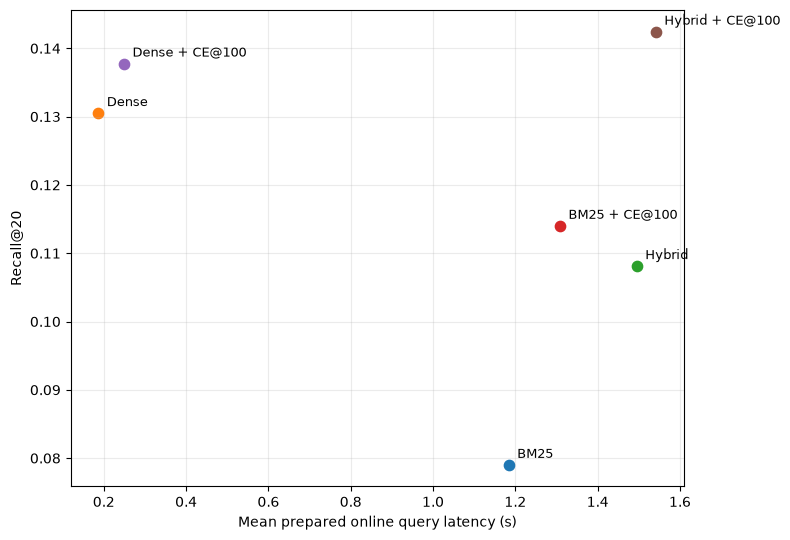

Figure data: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run\figures\effectiveness_latency_data.csv
PDF figure: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run\figures\effectiveness_vs_online_latency.pdf
PNG figure: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\results\full_run\figures\effectiveness_vs_online_latency.png


In [ ]:
# Generate effectiveness–latency figure from persisted experimental outputs.
#
# This deliberately reads the saved result tables rather than using manually
# entered values, so the figure remains tied directly to the validated
# experimental artefacts

FIGURE_DIR = RUN_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# 1. Load persisted experimental summaries

primary_eval = pd.read_csv(RUN_DIR / "evaluation_summary.csv")
ablation_eval = (pd.read_csv(ABLATION_DIR / "ablation_evaluation_summary.csv", index_col=0).rename_axis("configuration").reset_index())
query_summary = pd.read_csv(DEPLOYMENT_DIR / "query_summary.csv")


# 2. Construct one effectiveness table matching deployment configurations

first_stage_effectiveness = (primary_eval[primary_eval["method"].isin(["bm25", "dense", "hybrid"])][["method", "Recall@20"]].rename(columns={"method": "configuration"}))
reranked_effectiveness = (ablation_eval[["configuration", "Recall@20"]].copy())

effectiveness = pd.concat([first_stage_effectiveness, reranked_effectiveness], ignore_index=True)


# 3. Sanity checks before joining effectiveness and latency

primary_ce_recall = primary_eval.loc[primary_eval["method"] == "cross_encoder", "Recall@20"].item()
hybrid_ce100_recall = ablation_eval.loc[ablation_eval["configuration"] == "hybrid_ce_k100", "Recall@20"].item()

assert np.isclose(primary_ce_recall, hybrid_ce100_recall, rtol=0, atol=1e-12), ("Primary cross-encoder Recall@20 does not match hybrid_ce_k100 in the ablation results."

# Every configuration timed by the prepared benchmark should have a
# corresponding effectiveness measurement.

timed_configurations = set(query_summary["configuration"])
evaluated_configurations = set(effectiveness["configuration"])

missing_effectiveness = timed_configurations - evaluated_configurations
missing_latency = evaluated_configurations - timed_configurations

assert not missing_effectiveness, (f"Configurations have latency measurements but no effectiveness result: {sorted(missing_effectiveness)}")

assert not missing_latency, (f"Configurations have effectiveness results but no latency measurement: {sorted(missing_latency)}")



# 4. Join effectiveness and prepared online latency
figure_data = effectiveness.merge(query_summary[["configuration", "mean_query_seconds"]], on="configuration", how="inner", validate="one_to_one")

figure_data = figure_data[["configuration", "mean_query_seconds", "Recall@20"]].sort_values("configuration").reset_index(drop=True)

# Save the exact data used to generate the figure.
figure_data.to_csv(FIGURE_DIR / "effectiveness_latency_data.csv",index=False)

display(figure_data)



# 5. Select the configurations shown in the dissertation figure
plot_configurations = ["bm25", "dense", "hybrid", "bm25_ce_k100", "dense_ce_k100", "hybrid_ce_k100"]

plot_data = (figure_data.set_index("configuration").loc[plot_configurations].reset_index())


display(plot_data)

# 6. Plot

display_names = {"bm25": "BM25", "dense": "Dense", "hybrid": "Hybrid", "bm25_ce_k100": "BM25 + CE@100", "dense_ce_k100": "Dense + CE@100", "hybrid_ce_k100": "Hybrid + CE@100"}

fig, ax = plt.subplots(figsize=(8, 5.5))

for _, row in plot_data.iterrows():
    x = row["mean_query_seconds"]
    y = row["Recall@20"]
    configuration = row["configuration"]

    ax.scatter(x, y, s=55)

    ax.annotate(display_names[configuration], (x, y), xytext=(6, 5), textcoords="offset points", fontsize=9)

ax.set_xlabel("Mean prepared online query latency (s)")
ax.set_ylabel("Recall@20")
ax.grid(alpha=0.25)

fig.tight_layout()

pdf_path = FIGURE_DIR / "effectiveness_vs_online_latency.pdf"
png_path = FIGURE_DIR / "effectiveness_vs_online_latency.png"

fig.savefig(pdf_path, bbox_inches="tight")

fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure data:", FIGURE_DIR / "effectiveness_latency_data.csv")
print("PDF figure:", pdf_path)
print("PNG figure:", png_path)